# Based on new label cropped dataset

# TARGETED RERUN

# Lib

In [1]:
import os
import glob
from pathlib import Path
from PIL import Image
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
import math
import random
from collections import defaultdict
from torch.utils.data import Sampler, BatchSampler, DataLoader
import copy


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))

torch: 2.10.0+cu128
torch cuda: 12.8
cuda available: True
gpu: Tesla T4
capability: (7, 5)


# Dir


In [3]:
#if local need change here
dataset_dir = Path("/kaggle/input/datasets/duongnguyenquy/mosquitoes-compsci760")

image_dir = dataset_dir / "image_crop_new/image_crop_new"
annotation_path = image_dir / "cropped_annotations.csv"

#image_dir = dataset_dir / "images/images" #original (not cropped images)
#annotation_path = dataset_dir / "labels/annotations.csv" #original dataset's csv


annotations = pd.read_csv(annotation_path)
annotations.head()

,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,source_image
0,train_00000_crop.jpeg,340,550,0,0,340,550,albopictus,train_00000.jpeg
1,train_00001_crop.jpeg,1050,1093,0,0,1050,1093,albopictus,train_00001.jpeg
2,train_00002_crop.jpeg,439,750,0,0,439,750,albopictus,train_00002.jpeg
3,train_00003_crop.jpeg,417,462,0,0,417,462,albopictus,train_00003.jpeg
4,train_00004_crop.jpeg,568,776,0,0,568,776,culex,train_00004.jpeg


In [4]:
image_df = (
    annotations.groupby("img_fName")["class_label"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

print("Number of images:", len(image_df))
print(image_df["class_label"].value_counts())
image_df.head()

Number of images: 10485
class_label
albopictus            4655
culex                 4638
culiseta               632
japonicus-koreicus     429
anopheles               84
aegypti                 47
Name: count, dtype: int64


,img_fName,class_label
0,train_00000_crop.jpeg,albopictus
1,train_00001_crop.jpeg,albopictus
2,train_00002_crop.jpeg,albopictus
3,train_00003_crop.jpeg,albopictus
4,train_00004_crop.jpeg,culex


# Label Processing

In [5]:
label_encoder = LabelEncoder()
image_df["label_id"] = label_encoder.fit_transform(image_df["class_label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print(class_names)
print("Num classes:", num_classes)

['aegypti', 'albopictus', 'anopheles', 'culex', 'culiseta', 'japonicus-koreicus']
Num classes: 6


# Split

In [6]:
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=42,
    stratify=image_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7339
Val: 1573
Test: 1573


In [7]:
# Count samples per class
class_counts = train_df["label_id"].value_counts().sort_index()
print(class_counts)

#class_weights = 1.0 / class_counts #tune with different class_weights
class_weights = 1.0 / np.sqrt(class_counts)
print(class_weights)

label_id
0      33
1    3258
2      59
3    3247
4     442
5     300
Name: count, dtype: int64
label_id
0    0.174078
1    0.017520
2    0.130189
3    0.017549
4    0.047565
5    0.057735
Name: count, dtype: float64


In [8]:
train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)

val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

test_subset_df = test_df.groupby("label_id", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20), random_state=42)
).reset_index(drop=True)

print("Subset Train:", len(train_subset_df))
print("Subset Val:", len(val_subset_df))
print("Subset Test:", len(test_subset_df))

Subset Train: 283
Subset Val: 100
Subset Test: 99


/tmp/ipykernel_23/1350935851.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_subset_df = train_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_23/1350935851.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_subset_df = val_df.groupby("label_id", group_keys=False).apply(
/tmp/ipykernel_23/1350935851.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

# Augmentation / Preprocessing

In [9]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Dataset

In [10]:
class MosquitoImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        #self.image_paths = df["label_id"].values
        #self.labels = df.iloc[:, -1].values
        self.image_paths = df['img_fName'].astype(str).values
        self.labels = df['label_id'].values

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_dir / self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# DataLoaders

In [11]:
train_dataset = MosquitoImageDataset(train_df, image_dir, transform=train_transform)
val_dataset = MosquitoImageDataset(val_df, image_dir, transform=eval_transform)
test_dataset = MosquitoImageDataset(test_df, image_dir, transform=eval_transform)

# Subset
# train_dataset = MosquitoImageDataset(train_subset_df, image_dir, transform=train_transform)
# val_dataset = MosquitoImageDataset(val_subset_df, image_dir, transform=eval_transform)
# test_dataset = MosquitoImageDataset(test_subset_df, image_dir, transform=eval_transform)


val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Model Setup

In [12]:
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)

def create_model(model_name, num_classes):
    if model_name == "efficientnet":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "mobilenet":
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model

# Imbalance Handling Setup

In [13]:
# WeightedRandomSampler
sample_weights = train_df["label_id"].map(class_weights).values
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # same size as train set
    replacement=True
)

# Sampler method
train_loader = DataLoader(
    train_dataset,   # your PyTorch Dataset
    batch_size=32,
    sampler=sampler,
    shuffle=False    # IMPORTANT: must be False when using sampler
)



# FocalLoss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none') 
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()



# PF-Loss
#PF-loss is not weighted loss and not sampler-based
class PFLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, inputs, targets):
        num_classes = inputs.size(1)

        probs = F.softmax(inputs, dim=1)
        true_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        class_means = []
        for c in range(num_classes):
            mask = (targets == c)
            if mask.any():
                q_c = true_probs[mask].mean()
            else:
                q_c = inputs.new_tensor(1.0)  # no loss contribution if class absent in batch
            class_means.append(q_c)

        class_means = torch.stack(class_means)
        loss = -torch.log(class_means + self.eps).mean()
        return loss



# StratifiedBatchSampler
class StratifiedBatchSampler(BatchSampler):
    def __init__(self, labels, batch_size, shuffle=True):
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_indices = {}
        for c in np.unique(self.labels):
            self.class_indices[c] = np.where(self.labels == c)[0].tolist()

        self.classes = list(self.class_indices.keys())
        self.num_classes = len(self.classes)
        self.num_batches = math.ceil(len(self.labels) / self.batch_size)

    def __iter__(self):
        pools = {c: idxs.copy() for c, idxs in self.class_indices.items()}

        if self.shuffle:
            for c in pools:
                random.shuffle(pools[c])

        for _ in range(self.num_batches):
            batch = []

            base = self.batch_size // self.num_classes
            remainder = self.batch_size % self.num_classes

            per_class = {c: base for c in self.classes}
            for c in self.classes[:remainder]:
                per_class[c] += 1

            for c in self.classes:
                need = per_class[c]

                if len(pools[c]) < need:
                    refill = self.class_indices[c].copy()
                    if self.shuffle:
                        random.shuffle(refill)
                    pools[c].extend(refill)

                batch.extend(pools[c][:need])
                pools[c] = pools[c][need:]

            if self.shuffle:
                random.shuffle(batch)

            yield batch

    def __len__(self):
        return self.num_batches

# Training loop definition

In [14]:
NUM_EPOCHS = 30

#if local need change here
output_dir = Path("/kaggle/working/")


def run_experiment(
    model_name,
    method_name,
    class_weights=None,
    class_weights_tensor=None,
    lr=1e-4,
    batch_size=32,
    gamma=1.0,
    weight_formula_name="inverse",
    num_epochs=None
):
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    
    epochs_to_run = num_epochs if num_epochs is not None else NUM_EPOCHS

    val_acc_history = []

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []

    model = create_model(model_name, num_classes)
    model = model.to(device)

    # freeze all
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze last layers
    if model_name == "efficientnet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "resnet50":
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "mobilenet":
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    # optimizer = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, model.parameters()),
    #     lr=1e-4 #tune with different lr
    # )
    optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # =========================
    # BALANCING METHODS
    # =========================

    if method_name == "weighted_sampler":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = nn.CrossEntropyLoss()
    
    elif method_name == "weighted_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    elif method_name == "focal_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)
    
    elif method_name == "pf_loss":
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )
    
        criterion = PFLoss()
    
    elif method_name == "stratified_sampling":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss()

    elif method_name == "weighted_sampler_weighted_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "weighted_sampler_focal_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)

    elif method_name == "stratified_weighted_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    elif method_name == "stratified_focal_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = FocalLoss(gamma=gamma, weight=class_weights_tensor)

    elif method_name == "weighted_sampler_pf_loss":
        sample_weights = train_df["label_id"].map(class_weights).values
        sample_weights = torch.tensor(sample_weights, dtype=torch.float)
    
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False
        )
    
        criterion = PFLoss()
    
    elif method_name == "stratified_pf_loss":
        stratified_batch_sampler = StratifiedBatchSampler(
            labels=train_df["label_id"].values,
            batch_size=batch_size,
            shuffle=True
        )
    
        train_loader_used = DataLoader(
            train_dataset,
            batch_sampler=stratified_batch_sampler,
            num_workers=0
        )
    
        criterion = PFLoss()

    else:
        raise ValueError(f"Unknown method_name: {method_name}")

    print(f"\n===== Training {model_name} with {method_name} =====")

    output_dir.mkdir(parents=True, exist_ok=True)

    patience = 5
    best_val_loss = float("inf")
    early_stop_counter = 0

    best_val_acc = 0
    val_acc = 0 
    best_val_balanced_acc = 0
    val_balanced_acc_history = []

    gamma_str = f"_g{gamma}" if method_name in ["focal_loss", "weighted_sampler_focal_loss", "stratified_focal_loss"] else ""
    run_name = f"{model_name}_{method_name}_lr{lr}_bs{batch_size}_ep{NUM_EPOCHS}{gamma_str}_w{weight_formula_name}"

    run_dir = output_dir / run_name ### make a folder for each run
    run_dir.mkdir(parents=True, exist_ok=True)
    
    for epoch in range(epochs_to_run):
        print(f"\n===== {model_name} | Epoch {epoch + 1}/{epochs_to_run} =====")

        # ================= TRAIN =================
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, targets) in enumerate(train_loader_used):
            images = images.to(device, non_blocking=True)
            targets = targets.long().to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            train_correct += (preds == targets).sum().item()
            train_total += targets.size(0)

            if batch_idx % 10 == 0:
                print(f"[Train] {model_name} | Epoch {epoch + 1} Batch {batch_idx}/{len(train_loader_used)} | Loss: {loss.item():.4f}")

        train_loss /= train_total
        train_acc = train_correct / train_total

        val_preds_all = []
        val_labels_all = []

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, (images, targets) in enumerate(val_loader):
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)

                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)
                val_preds_all.extend(preds.cpu().numpy())
                val_labels_all.extend(targets.cpu().numpy())

                if batch_idx % 10 == 0:
                    print(f"[Val] {model_name} | Epoch {epoch + 1} Batch {batch_idx}/{len(val_loader)} | Loss: {loss.item():.4f}")

        
        val_loss /= val_total
        val_acc = val_correct / val_total
        val_balanced_acc = balanced_accuracy_score(val_labels_all, val_preds_all)
        val_balanced_acc_history.append(val_balanced_acc) 
        

        val_acc_history.append(val_acc)


        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)

        print(
            f"{model_name} | Epoch {epoch + 1}/{epochs_to_run} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ================= CHECKPOINT =================
        # checkpoint_path = output_dir / f"{run_name}_epoch_{epoch + 1}.pth"
        # torch.save({
        #     "epoch": epoch + 1,
        #     "model_state_dict": model.state_dict(),
        #     "optimizer_state_dict": optimizer.state_dict(),
        #     "train_loss": train_loss,
        #     "val_loss": val_loss,
        #     "train_acc": train_acc,
        #     "val_acc": val_acc,
        #     "class_names": class_names
        # }, checkpoint_path)
        #stop saving at every epoch, keep only the _best.pth saving
        #5GB limit on output files saved

        # ================= EARLY STOPPING =================
        if val_balanced_acc > best_val_balanced_acc:
            best_val_balanced_acc = val_balanced_acc
            early_stop_counter = 0
            #torch.save({dir}, best_model_path)

            best_model_path = run_dir / f"{run_name}_best.pth"
            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "class_names": class_names
            }, best_model_path)

        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break


    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss_history, label="Train Loss")
    plt.plot(val_loss_history, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(run_dir / f"{run_name}_loss_curve.png", dpi=300)
    plt.show()
    
    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc_history, label="Train Accuracy")
    plt.plot(val_acc_history, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve - {run_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(run_dir / f"{run_name}_accuracy_curve.png", dpi=300)
    plt.show()
    

    return {
        "model": model_name,
        "method": method_name,
        "val_acc_history": val_acc_history,
        "best_val_acc": max(val_acc_history),
        "best_val_balanced_acc": best_val_balanced_acc, # use the tracked value, not max()
        "val_balanced_acc_history": val_balanced_acc_history,
        "final_val_acc": val_acc,
        "model_obj": model,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "train_acc_history": train_acc_history,
        "run_dir": str(run_dir)
    }

# Evalution defintion 

In [15]:
def evaluate_loader(model, loader):
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return {
        "preds": np.concatenate(all_preds),
        "labels": np.concatenate(all_labels),
        "probs": np.concatenate(all_probs)
    }

In [16]:
def get_class_weights(formula_name):
    class_counts = train_df["label_id"].value_counts().sort_index()

    if formula_name == "inverse":
        weights = 1.0 / class_counts

    elif formula_name == "sqrt_inverse":
        weights = 1.0 / np.sqrt(class_counts)

    elif formula_name == "log_inverse":
        weights = 1.0 / np.log(class_counts + 1)

    else:
        raise ValueError("Unknown class weight formula")

    return weights

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s]



===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 2.2150
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.9926
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.2789
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.8915
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.2385
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.7129
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.5177
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.9903
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.9061
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5816
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.1236
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.5425
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.9235
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 1.0580
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 1.0701
[Train] resnet50 | Epoch 1 Bat

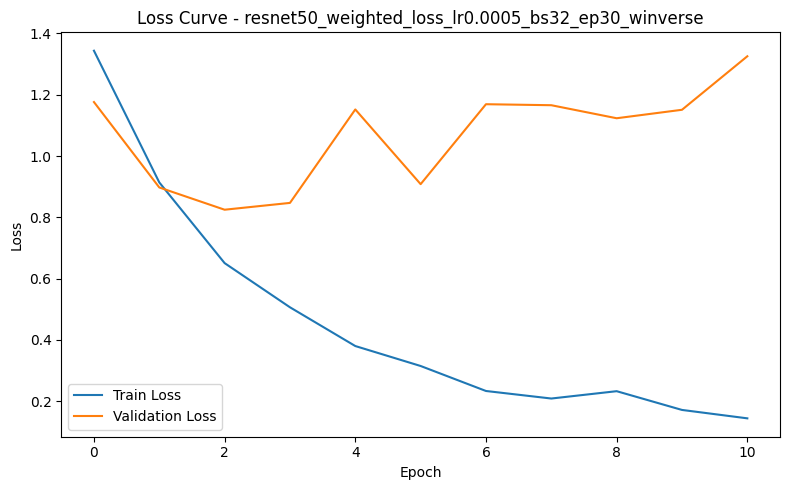

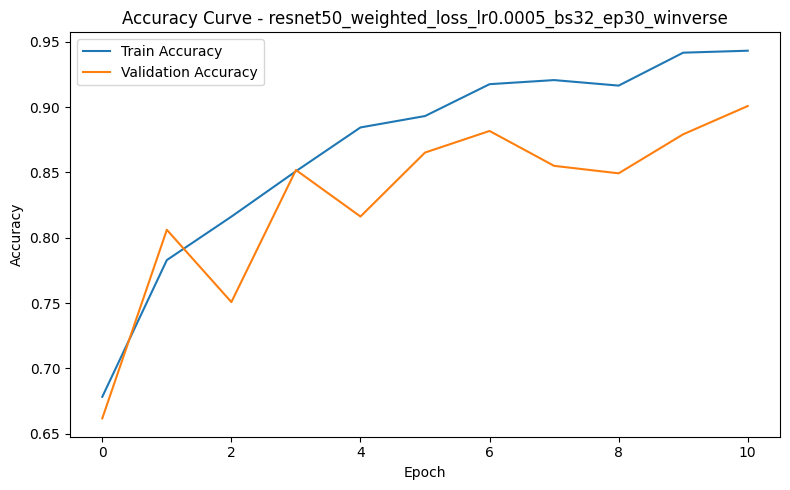


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 2.0997
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.1383
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.1738
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.8430
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.2518
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.3338
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.4282
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 1.1898
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.9579
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5694
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.0730
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.5443
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 1.0080
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.9784
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.9978
[Train] resnet50 | Epoch 1 Bat

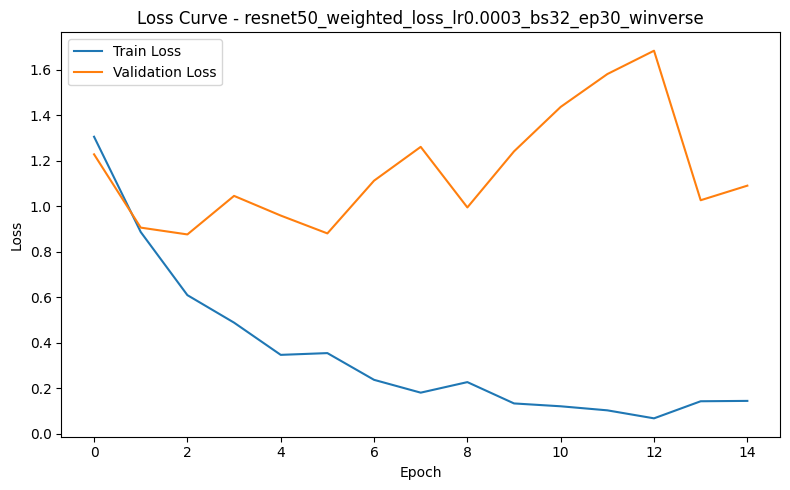

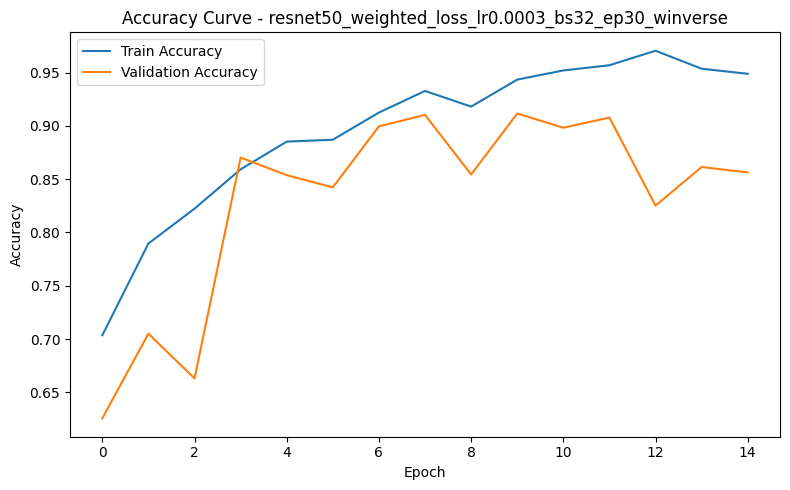


===== Training resnet50 with weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8395
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.9513
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 1.5147
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 1.4401
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 1.2704
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 1.8262
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 1.4927
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 1.4483
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 1.7672
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 1.0310
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 1.5878
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 1.1928
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 1.6836
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.9574
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.8862
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 1.0743
[Train] resnet50 | Epoch 1 Bat

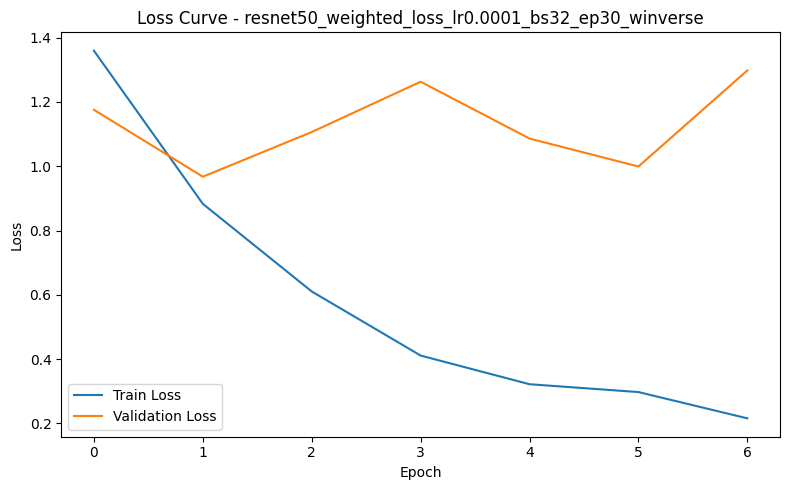

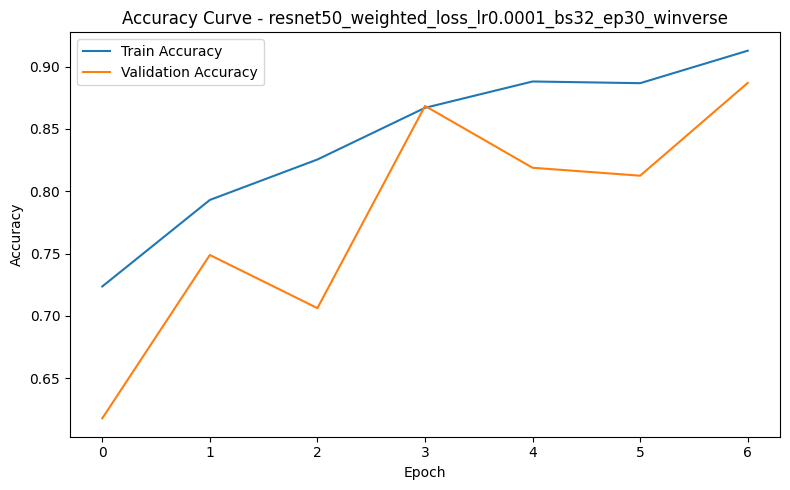


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0020
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0049
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0010
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0021
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0017
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0015
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0027
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0025
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0011
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0032
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0010
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 

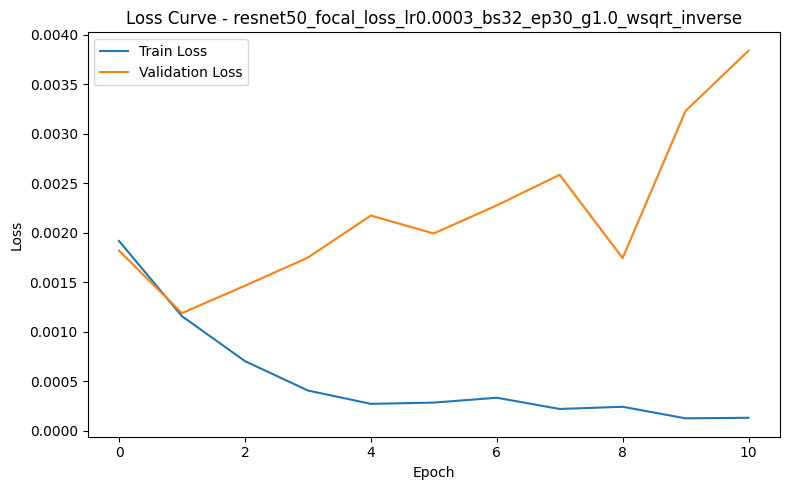

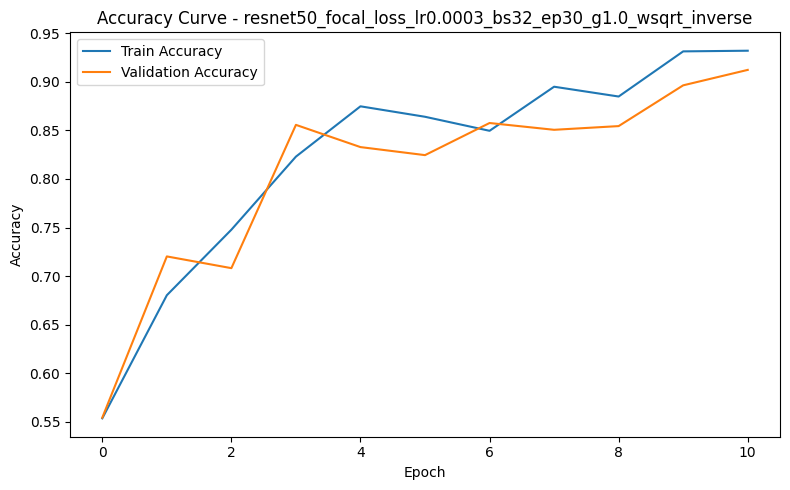


===== Training resnet50 with focal_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 0.0020
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 0.0053
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.0010
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.0007
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.0027
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.0017
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.0014
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.0033
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.0042
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.0014
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.0034
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.0009
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.0008
[Train] resnet50 | Epoch 1 Batch 

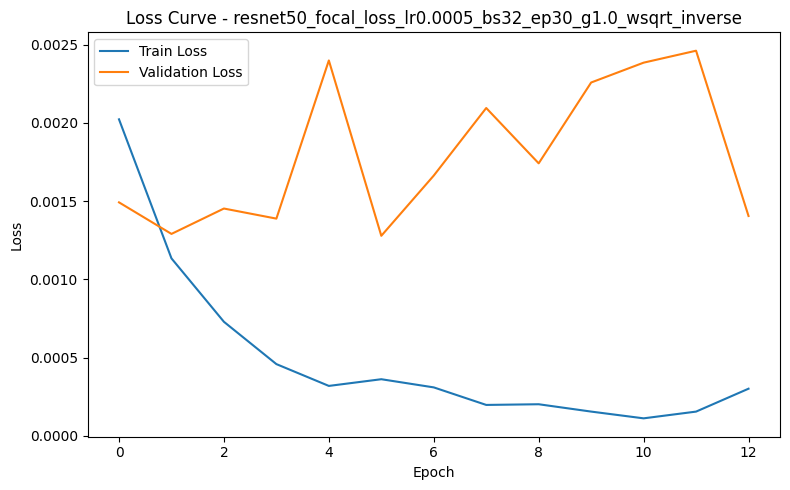

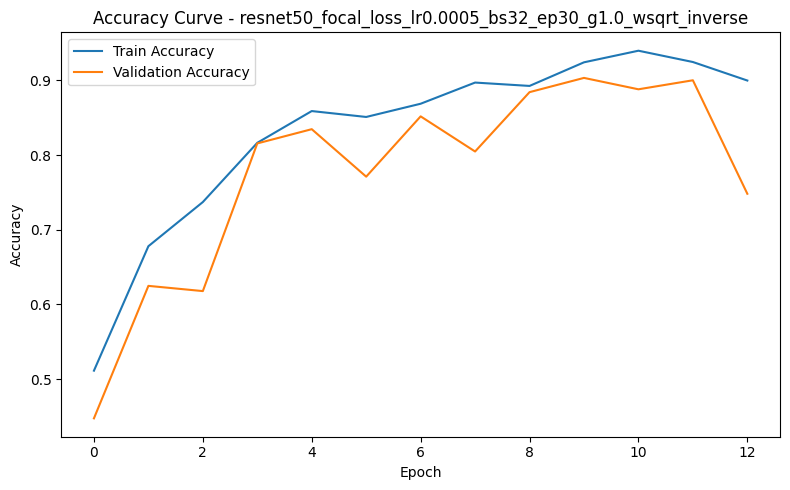


===== Training resnet50 with stratified_weighted_loss =====

===== resnet50 | Epoch 1/30 =====
[Train] resnet50 | Epoch 1 Batch 0/230 | Loss: 1.8122
[Train] resnet50 | Epoch 1 Batch 10/230 | Loss: 1.1321
[Train] resnet50 | Epoch 1 Batch 20/230 | Loss: 0.7423
[Train] resnet50 | Epoch 1 Batch 30/230 | Loss: 0.5477
[Train] resnet50 | Epoch 1 Batch 40/230 | Loss: 0.4804
[Train] resnet50 | Epoch 1 Batch 50/230 | Loss: 0.3665
[Train] resnet50 | Epoch 1 Batch 60/230 | Loss: 0.2910
[Train] resnet50 | Epoch 1 Batch 70/230 | Loss: 0.2593
[Train] resnet50 | Epoch 1 Batch 80/230 | Loss: 0.2132
[Train] resnet50 | Epoch 1 Batch 90/230 | Loss: 0.1728
[Train] resnet50 | Epoch 1 Batch 100/230 | Loss: 0.1702
[Train] resnet50 | Epoch 1 Batch 110/230 | Loss: 0.1244
[Train] resnet50 | Epoch 1 Batch 120/230 | Loss: 0.1578
[Train] resnet50 | Epoch 1 Batch 130/230 | Loss: 0.2452
[Train] resnet50 | Epoch 1 Batch 140/230 | Loss: 0.2319
[Train] resnet50 | Epoch 1 Batch 150/230 | Loss: 0.2147
[Train] resnet50 | 

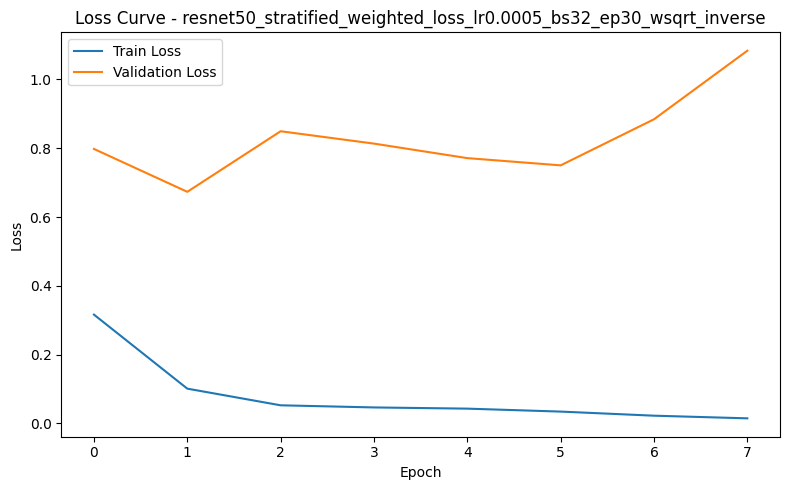

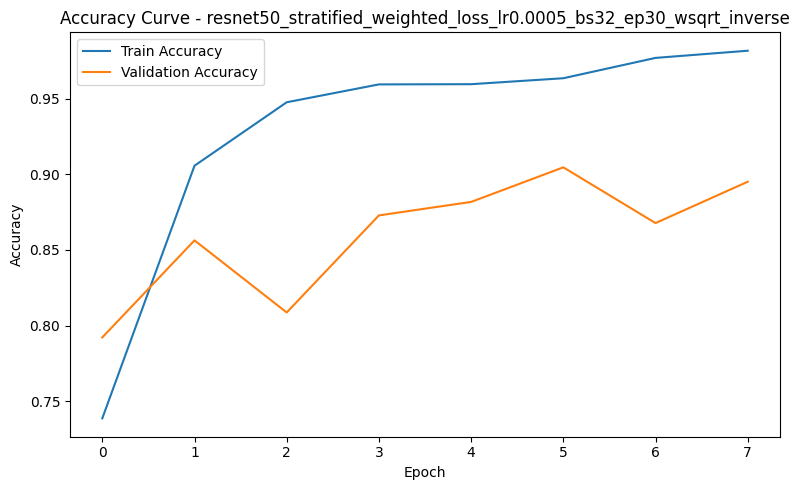

In [17]:
# =============================================
# TARGETED RERUN — specific configs only
# =============================================

best_overall_acc = 0
best_overall_balanced_acc = 0
best_model_state = None
best_run_name = None
trained_models = {}
all_results = []

# exact configs to rerun
configs_to_run = [
    {"method": "weighted_loss",            "weight_formula": "inverse",      "lr": 5e-4},
    {"method": "weighted_loss",            "weight_formula": "inverse",      "lr": 3e-4},
    {"method": "weighted_loss",            "weight_formula": "inverse",      "lr": 1e-4},
    {"method": "focal_loss",               "weight_formula": "sqrt_inverse", "lr": 3e-4},
    {"method": "focal_loss",               "weight_formula": "sqrt_inverse", "lr": 5e-4},
    {"method": "stratified_weighted_loss", "weight_formula": "sqrt_inverse", "lr": 5e-4},
]

for config in configs_to_run:
    method_name  = config["method"]
    formula_name = config["weight_formula"]
    lr           = config["lr"]

    class_weights = get_class_weights(formula_name)
    class_weights_tensor = torch.tensor(
        class_weights.values, dtype=torch.float32).to(device)

    gamma = 1.0

    result = run_experiment(
        model_name="resnet50",
        method_name=method_name,
        class_weights=class_weights,
        class_weights_tensor=class_weights_tensor,
        lr=lr,
        batch_size=32,
        gamma=gamma,
        weight_formula_name=formula_name,
        num_epochs=NUM_EPOCHS
    )

    result["lr"] = lr
    result["batch_size"] = 32
    result["gamma"] = gamma
    result["weight_formula"] = formula_name
    all_results.append(result)

    key = f"resnet50_{method_name}_lr{lr}_bs32_g{gamma}_w{formula_name}"
    trained_models[key] = result["model_obj"]

    if result["best_val_balanced_acc"] > best_overall_balanced_acc:
        best_overall_balanced_acc = result["best_val_balanced_acc"]
        best_overall_acc = result["best_val_acc"]
        best_model_state = copy.deepcopy(result["model_obj"].state_dict())
        best_run_name = f"resnet50_{method_name}_lr{lr}_bs32_ep{NUM_EPOCHS}_g{gamma}_w{formula_name}"

In [18]:
# Save all 6 methods — no ranking needed with only 6 runs
results_df = pd.DataFrame(all_results)

for _, row in results_df.iterrows():
    model_obj = row["model_obj"]
    
    save_path = output_dir / f"{row['method']}_w{row['weight_formula']}_lr{row['lr']}.pth"
    torch.save({
        "model_state_dict": model_obj.state_dict(),
        "model_name": "resnet50",
        "num_classes": num_classes,
        "run_name": f"resnet50_{row['method']}_w{row['weight_formula']}_lr{row['lr']}",
        "best_val_balanced_acc": row["best_val_balanced_acc"],
        "best_val_acc": row["best_val_acc"],
    }, save_path)
    
    print(f"Saved: {save_path}")

Saved: /kaggle/working/weighted_loss_winverse_lr0.0005.pth
Saved: /kaggle/working/weighted_loss_winverse_lr0.0003.pth
Saved: /kaggle/working/weighted_loss_winverse_lr0.0001.pth
Saved: /kaggle/working/focal_loss_wsqrt_inverse_lr0.0003.pth
Saved: /kaggle/working/focal_loss_wsqrt_inverse_lr0.0005.pth
Saved: /kaggle/working/stratified_weighted_loss_wsqrt_inverse_lr0.0005.pth


## validation improvements across all models + methods

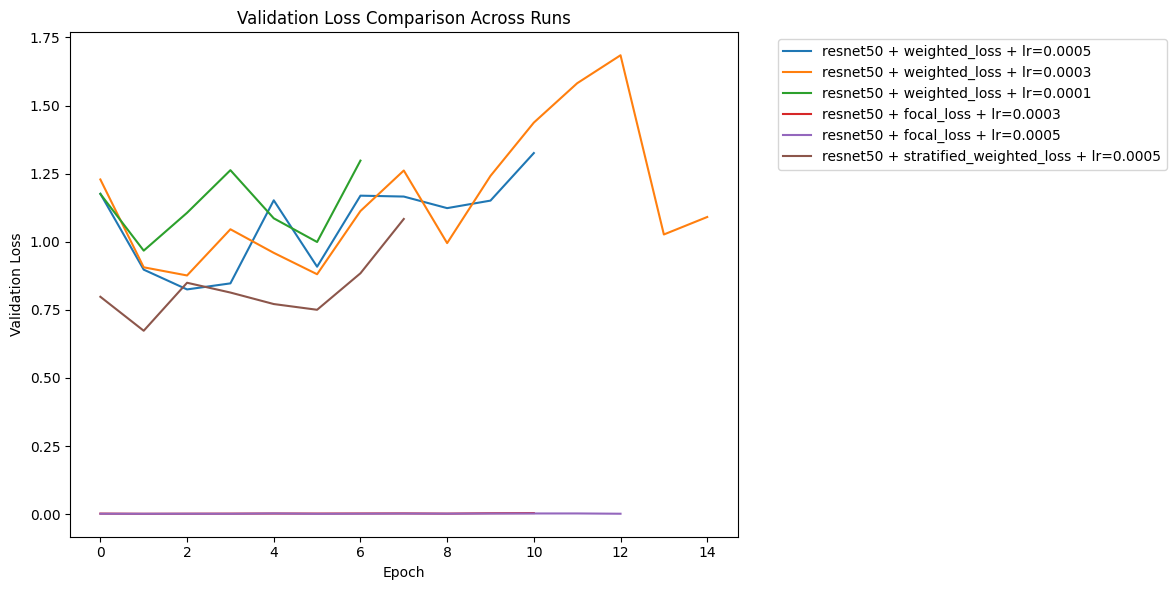

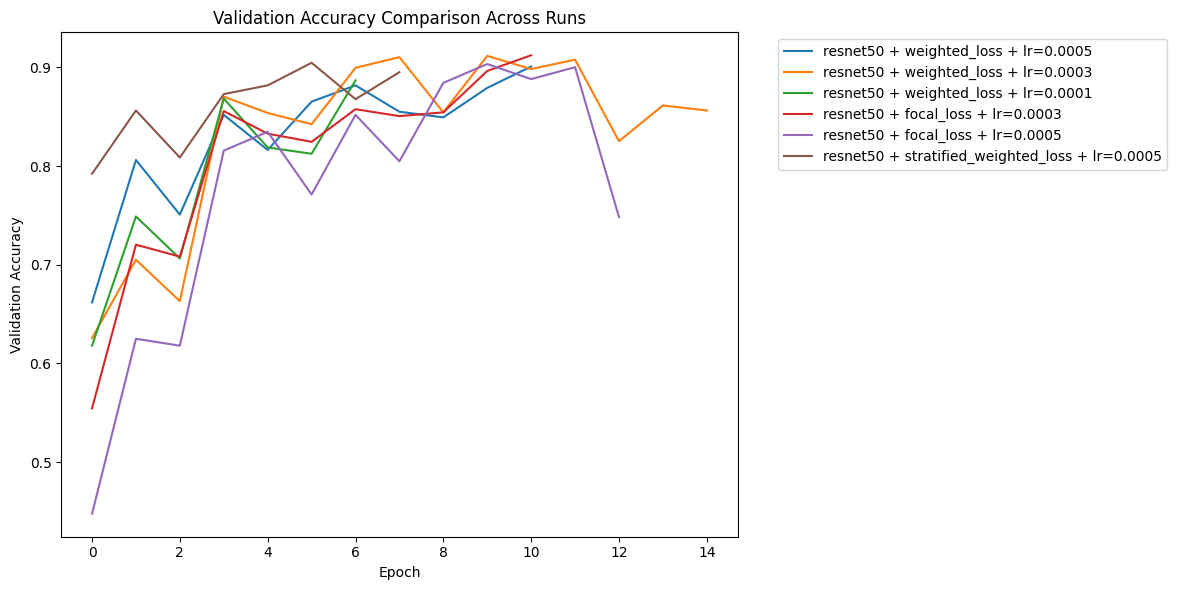

In [19]:
# compare validation loss across all model + method combinations
plt.figure(figsize=(12, 6))

for r in all_results:
    label = f"{r['model']} + {r['method']} + lr={r['lr']}"
    plt.plot(r["val_loss_history"], label=label)

plt.title("Validation Loss Comparison Across Runs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



# compare validation accuracy across all model + method combinations
plt.figure(figsize=(12, 6))

for r in all_results:
    label = f"{r['model']} + {r['method']} + lr={r['lr']}"
    plt.plot(r["val_acc_history"], label=label)

plt.title("Validation Accuracy Comparison Across Runs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
# collect predictions for ALL sets
all_train_results = {}
all_val_results = {}
all_test_results = {}

for name, model in trained_models.items():
    print(f"\nEvaluating {name}...")

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_train_results[name] = evaluate_loader(model, train_loader)
    all_val_results[name]   = evaluate_loader(model, val_loader)
    all_test_results[name]  = evaluate_loader(model, test_loader)


Evaluating resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse...

Evaluating resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse...

Evaluating resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse...

Evaluating resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse...

Evaluating resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse...



TRAIN Evaluation: resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.9636
Balanced Accuracy:  0.9738
Macro Precision:    0.9462
Macro Recall:       0.9738
Macro F1:           0.9590
Weighted F1:        0.9640
ROC-AUC:            0.9989

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.992032,1.000000,0.996000,249
1,albopictus,0.986235,0.959811,0.972843,2538
2,anopheles,0.881266,0.997015,0.935574,335
3,culex,0.988110,0.957870,0.972755,2516
4,culiseta,0.898522,0.984881,0.939722,926
5,japonicus-koreicus,0.931210,0.943226,0.937179,775



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9920    1.0000    0.9960       249
        albopictus     0.9862    0.9598    0.9728      2538
         anopheles     0.8813    0.9970    0.9356       335
             culex     0.9881    0.9579    0.9728      2516
          culiseta     0.8985    0.9849    0.9397       926
japonicus-koreicus     0.9312    0.9432    0.9372       775

          accuracy                         0.9636      7339
         macro avg     0.9462    0.9738    0.9590      7339
      weighted avg     0.9654    0.9636    0.9640      7339



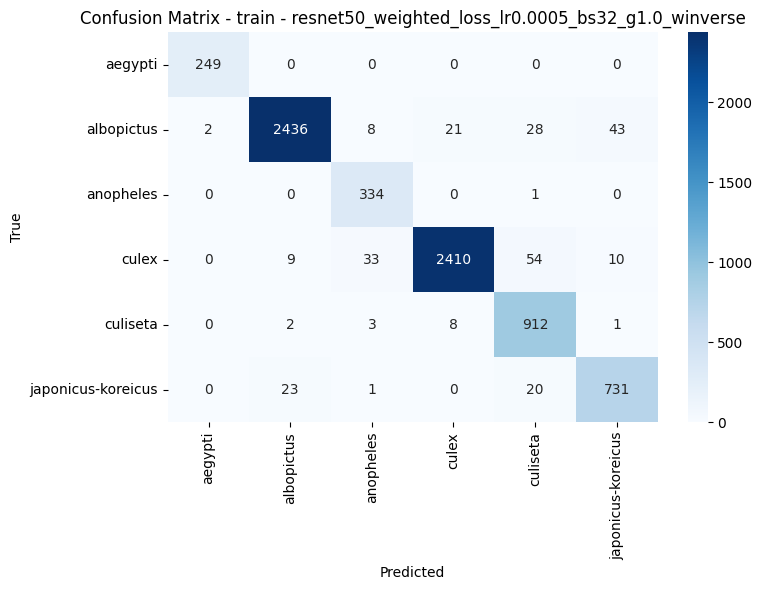


TRAIN Evaluation: resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.9563
Balanced Accuracy:  0.9755
Macro Precision:    0.9376
Macro Recall:       0.9755
Macro F1:           0.9541
Weighted F1:        0.9570
ROC-AUC:            0.9989

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.921986,0.996169,0.957643,261
1,albopictus,0.994664,0.899477,0.944679,2487
2,anopheles,0.969359,1.000000,0.984441,348
3,culex,0.985075,0.980453,0.982759,2558
4,culiseta,0.956663,0.984392,0.970330,897
5,japonicus-koreicus,0.797959,0.992386,0.884615,788



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9220    0.9962    0.9576       261
        albopictus     0.9947    0.8995    0.9447      2487
         anopheles     0.9694    1.0000    0.9844       348
             culex     0.9851    0.9805    0.9828      2558
          culiseta     0.9567    0.9844    0.9703       897
japonicus-koreicus     0.7980    0.9924    0.8846       788

          accuracy                         0.9563      7339
         macro avg     0.9376    0.9755    0.9541      7339
      weighted avg     0.9618    0.9563    0.9570      7339



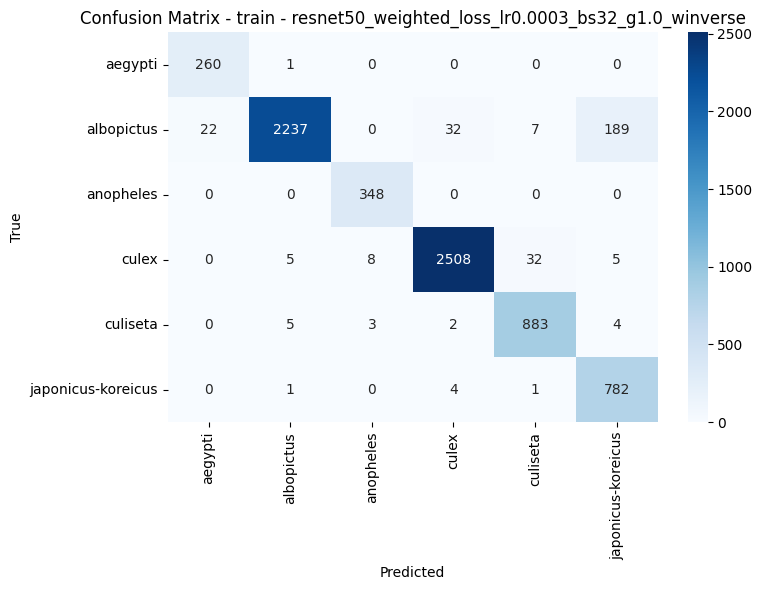


TRAIN Evaluation: resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.9524
Balanced Accuracy:  0.9616
Macro Precision:    0.9438
Macro Recall:       0.9616
Macro F1:           0.9518
Weighted F1:        0.9528
ROC-AUC:            0.9981

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.970588,0.996226,0.983240,265
1,albopictus,0.967519,0.966342,0.966930,2466
2,anopheles,0.954930,0.954930,0.954930,355
3,culex,0.987261,0.924086,0.954629,2516
4,culiseta,0.860783,0.988506,0.920233,957
5,japonicus-koreicus,0.922013,0.939744,0.930794,780



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9706    0.9962    0.9832       265
        albopictus     0.9675    0.9663    0.9669      2466
         anopheles     0.9549    0.9549    0.9549       355
             culex     0.9873    0.9241    0.9546      2516
          culiseta     0.8608    0.9885    0.9202       957
japonicus-koreicus     0.9220    0.9397    0.9308       780

          accuracy                         0.9524      7339
         macro avg     0.9438    0.9616    0.9518      7339
      weighted avg     0.9550    0.9524    0.9528      7339



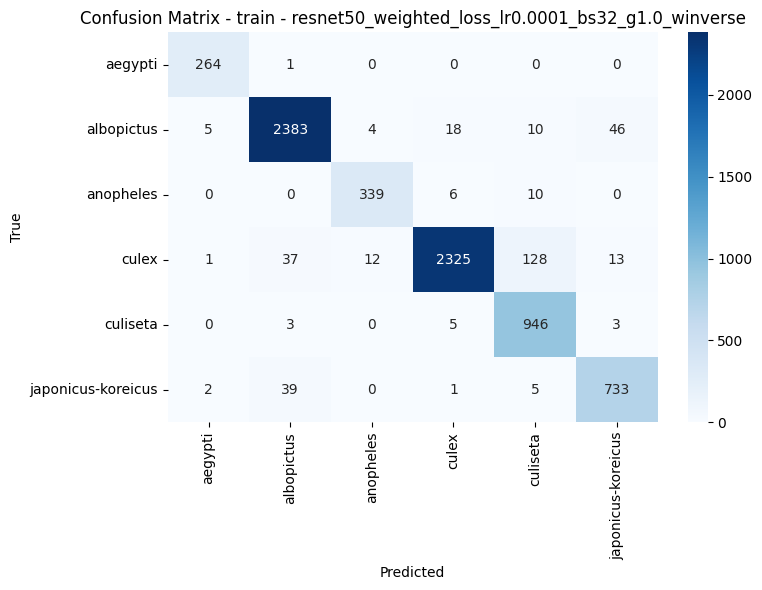


TRAIN Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9673
Balanced Accuracy:  0.9750
Macro Precision:    0.9577
Macro Recall:       0.9750
Macro F1:           0.9661
Weighted F1:        0.9674
ROC-AUC:            0.9990

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.967153,1.000000,0.983302,265
1,albopictus,0.973483,0.969976,0.971726,2498
2,anopheles,0.952381,1.000000,0.975610,360
3,culex,0.986224,0.960537,0.973211,2534
4,culiseta,0.948718,0.979052,0.963646,907
5,japonicus-koreicus,0.918136,0.940645,0.929254,775



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9672    1.0000    0.9833       265
        albopictus     0.9735    0.9700    0.9717      2498
         anopheles     0.9524    1.0000    0.9756       360
             culex     0.9862    0.9605    0.9732      2534
          culiseta     0.9487    0.9791    0.9636       907
japonicus-koreicus     0.9181    0.9406    0.9293       775

          accuracy                         0.9673      7339
         macro avg     0.9577    0.9750    0.9661      7339
      weighted avg     0.9677    0.9673    0.9674      7339



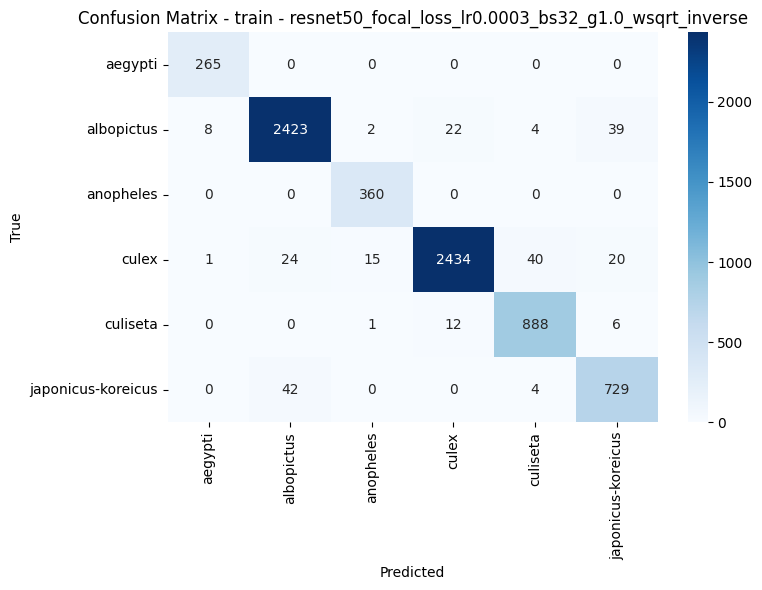


TRAIN Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8745
Balanced Accuracy:  0.9229
Macro Precision:    0.8357
Macro Recall:       0.9229
Macro F1:           0.8625
Weighted F1:        0.8805
ROC-AUC:            0.9948

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.844068,1.000000,0.915441,249
1,albopictus,0.984399,0.746451,0.849069,2536
2,anopheles,0.713348,0.964497,0.820126,338
3,culex,0.969268,0.932322,0.950436,2571
4,culiseta,0.938462,0.903189,0.920488,878
5,japonicus-koreicus,0.564636,0.990874,0.719356,767



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.8441    1.0000    0.9154       249
        albopictus     0.9844    0.7465    0.8491      2536
         anopheles     0.7133    0.9645    0.8201       338
             culex     0.9693    0.9323    0.9504      2571
          culiseta     0.9385    0.9032    0.9205       878
japonicus-koreicus     0.5646    0.9909    0.7194       767

          accuracy                         0.8745      7339
         macro avg     0.8357    0.9229    0.8625      7339
      weighted avg     0.9125    0.8745    0.8805      7339



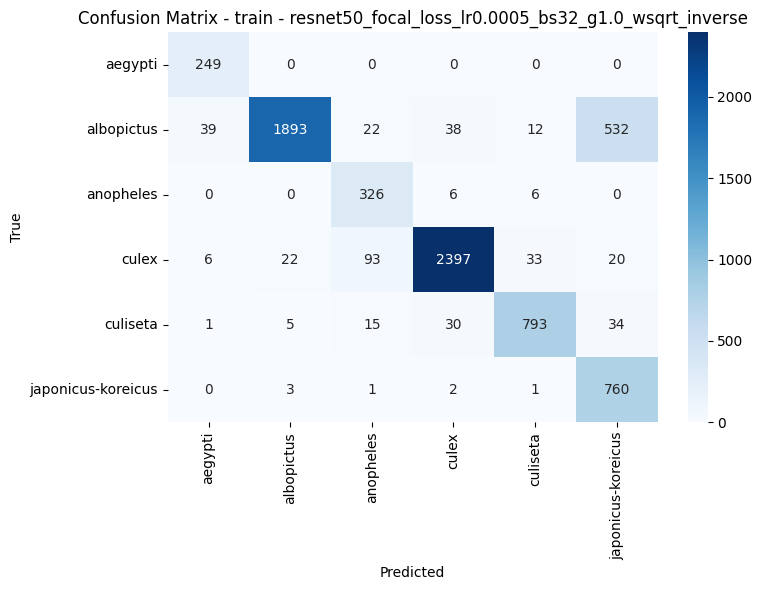


TRAIN Evaluation: resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9569
Balanced Accuracy:  0.9786
Macro Precision:    0.9490
Macro Recall:       0.9786
Macro F1:           0.9620
Weighted F1:        0.9574
ROC-AUC:            0.9991

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.980989,1.000000,0.990403,258
1,albopictus,0.979576,0.964051,0.971751,2587
2,anopheles,0.982143,1.000000,0.990991,330
3,culex,0.995610,0.911576,0.951742,2488
4,culiseta,0.847826,1.000000,0.917647,936
5,japonicus-koreicus,0.907635,0.995946,0.949742,740



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.9810    1.0000    0.9904       258
        albopictus     0.9796    0.9641    0.9718      2587
         anopheles     0.9821    1.0000    0.9910       330
             culex     0.9956    0.9116    0.9517      2488
          culiseta     0.8478    1.0000    0.9176       936
japonicus-koreicus     0.9076    0.9959    0.9497       740

          accuracy                         0.9569      7339
         macro avg     0.9490    0.9786    0.9620      7339
      weighted avg     0.9611    0.9569    0.9574      7339



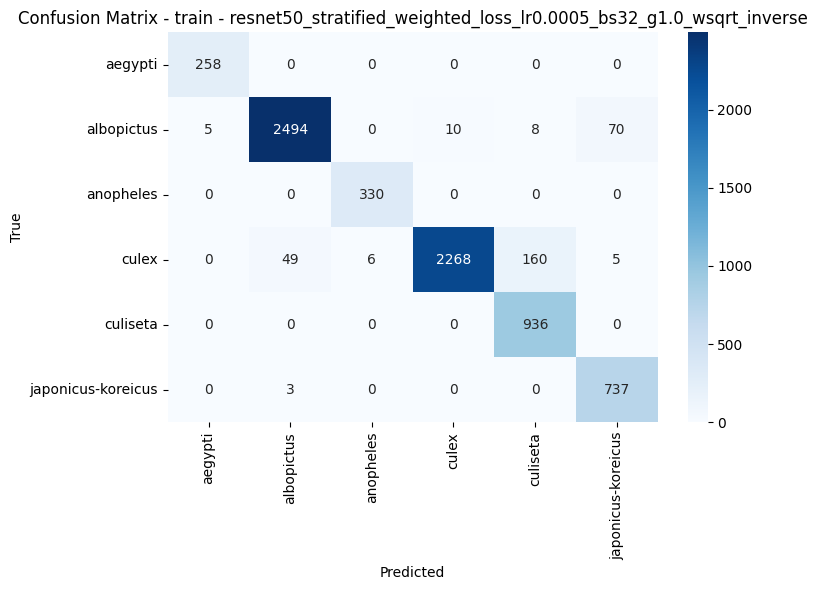


VALIDATION Evaluation: resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.9008
Balanced Accuracy:  0.5912
Macro Precision:    0.5397
Macro Recall:       0.5912
Macro F1:           0.5589
Weighted F1:        0.9039
ROC-AUC:            0.9477

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.951399,0.925501,0.938272,698
2,anopheles,0.166667,0.307692,0.216216,13
3,culex,0.965926,0.938129,0.951825,695
4,culiseta,0.623077,0.852632,0.720000,95
5,japonicus-koreicus,0.531250,0.523077,0.527132,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9514    0.9255    0.9383       698
         anopheles     0.1667    0.3077    0.2162        13
             culex     0.9659    0.9381    0.9518       695
          culiseta     0.6231    0.8526    0.7200        95
japonicus-koreicus     0.5312    0.5231    0.5271        65

          accuracy                         0.9008      1573
         macro avg     0.5397    0.5912    0.5589      1573
      weighted avg     0.9099    0.9008    0.9039      1573



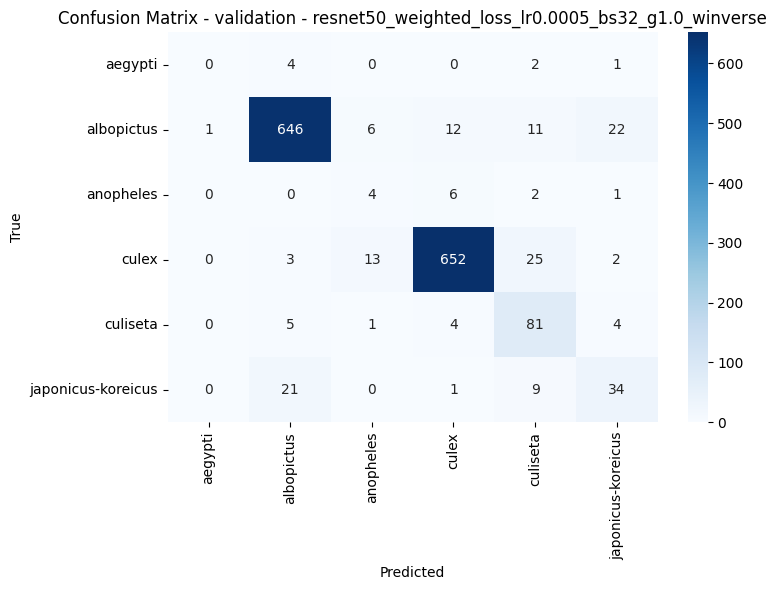


VALIDATION Evaluation: resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.8563
Balanced Accuracy:  0.6434
Macro Precision:    0.5755
Macro Recall:       0.6434
Macro F1:           0.5829
Weighted F1:        0.8740
ROC-AUC:            0.9406

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.250000,0.142857,0.181818,7
1,albopictus,0.965278,0.796562,0.872841,698
2,anopheles,0.250000,0.384615,0.303030,13
3,culex,0.952243,0.946763,0.949495,695
4,culiseta,0.750000,0.789474,0.769231,95
5,japonicus-koreicus,0.285714,0.800000,0.421053,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9653    0.7966    0.8728       698
         anopheles     0.2500    0.3846    0.3030        13
             culex     0.9522    0.9468    0.9495       695
          culiseta     0.7500    0.7895    0.7692        95
japonicus-koreicus     0.2857    0.8000    0.4211        65

          accuracy                         0.8563      1573
         macro avg     0.5755    0.6434    0.5829      1573
      weighted avg     0.9093    0.8563    0.8740      1573



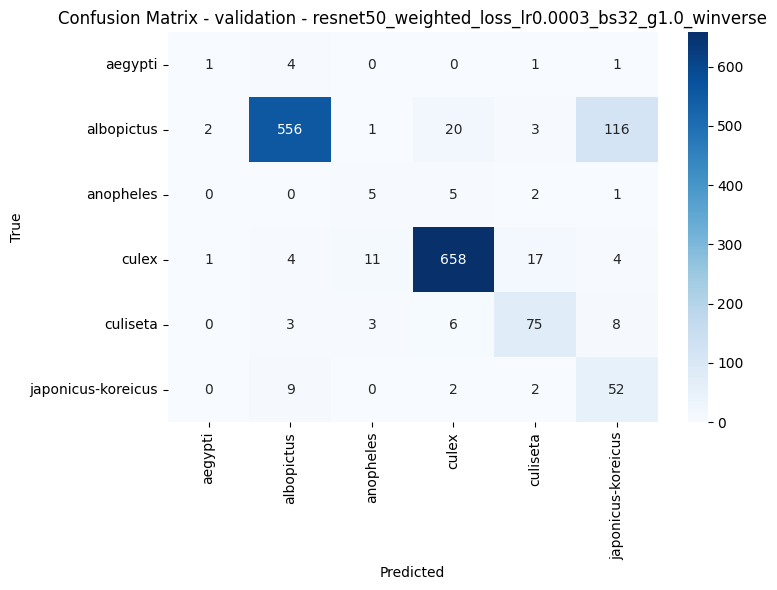


VALIDATION Evaluation: resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.8868
Balanced Accuracy:  0.5418
Macro Precision:    0.5236
Macro Recall:       0.5418
Macro F1:           0.5276
Weighted F1:        0.8896
ROC-AUC:            0.9267

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.250000,0.142857,0.181818,7
1,albopictus,0.948830,0.929799,0.939219,698
2,anopheles,0.000000,0.000000,0.000000,13
3,culex,0.952522,0.923741,0.937911,695
4,culiseta,0.552846,0.715789,0.623853,95
5,japonicus-koreicus,0.437500,0.538462,0.482759,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9488    0.9298    0.9392       698
         anopheles     0.0000    0.0000    0.0000        13
             culex     0.9525    0.9237    0.9379       695
          culiseta     0.5528    0.7158    0.6239        95
japonicus-koreicus     0.4375    0.5385    0.4828        65

          accuracy                         0.8868      1573
         macro avg     0.5236    0.5418    0.5276      1573
      weighted avg     0.8945    0.8868    0.8896      1573



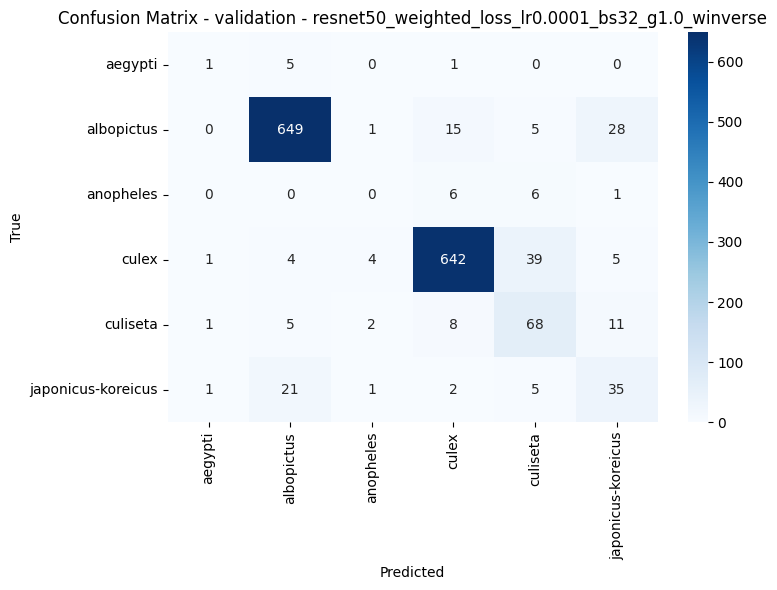


VALIDATION Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9123
Balanced Accuracy:  0.6124
Macro Precision:    0.6276
Macro Recall:       0.6124
Macro F1:           0.6150
Weighted F1:        0.9128
ROC-AUC:            0.9227

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.333333,0.285714,0.307692,7
1,albopictus,0.952174,0.941261,0.946686,698
2,anopheles,0.285714,0.153846,0.200000,13
3,culex,0.955460,0.956835,0.956147,695
4,culiseta,0.769231,0.736842,0.752688,95
5,japonicus-koreicus,0.469880,0.600000,0.527027,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3333    0.2857    0.3077         7
        albopictus     0.9522    0.9413    0.9467       698
         anopheles     0.2857    0.1538    0.2000        13
             culex     0.9555    0.9568    0.9561       695
          culiseta     0.7692    0.7368    0.7527        95
japonicus-koreicus     0.4699    0.6000    0.5270        65

          accuracy                         0.9123      1573
         macro avg     0.6276    0.6124    0.6150      1573
      weighted avg     0.9144    0.9123    0.9128      1573



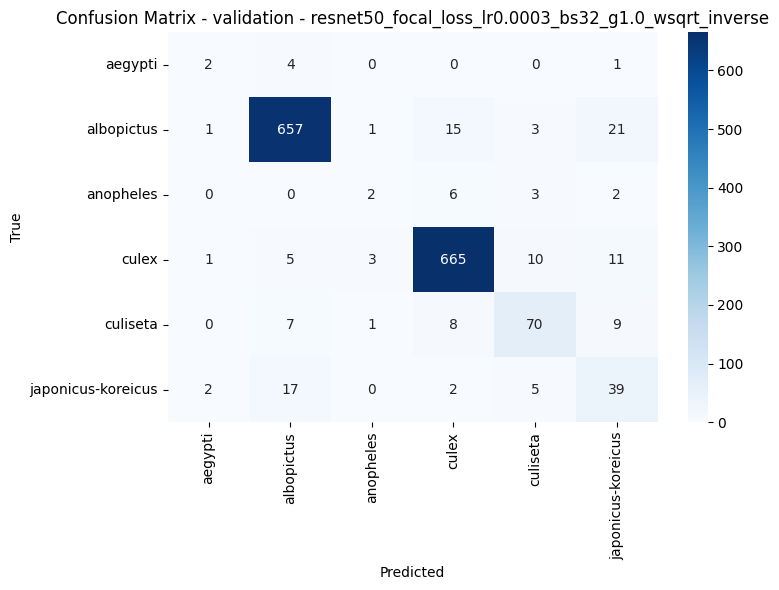


VALIDATION Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.7483
Balanced Accuracy:  0.6390
Macro Precision:    0.5270
Macro Recall:       0.6390
Macro F1:           0.5249
Weighted F1:        0.7969
ROC-AUC:            0.9287

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.375000,0.428571,0.400000,7
1,albopictus,0.947266,0.694842,0.801653,698
2,anopheles,0.070000,0.538462,0.123894,13
3,culex,0.928918,0.827338,0.875190,695
4,culiseta,0.652632,0.652632,0.652632,95
5,japonicus-koreicus,0.188285,0.692308,0.296053,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.3750    0.4286    0.4000         7
        albopictus     0.9473    0.6948    0.8017       698
         anopheles     0.0700    0.5385    0.1239        13
             culex     0.9289    0.8273    0.8752       695
          culiseta     0.6526    0.6526    0.6526        95
japonicus-koreicus     0.1883    0.6923    0.2961        65

          accuracy                         0.7483      1573
         macro avg     0.5270    0.6390    0.5249      1573
      weighted avg     0.8802    0.7483    0.7969      1573



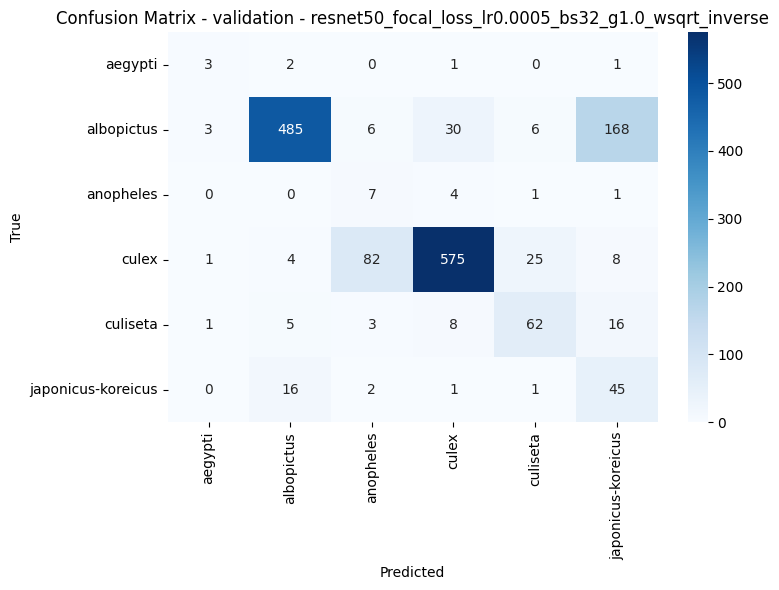


VALIDATION Evaluation: resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8951
Balanced Accuracy:  0.5769
Macro Precision:    0.6688
Macro Recall:       0.5769
Macro F1:           0.5614
Weighted F1:        0.8967
ROC-AUC:            0.9360

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,1.000000,0.142857,0.250000,7
1,albopictus,0.939691,0.959885,0.949681,698
2,anopheles,0.000000,0.000000,0.000000,13
3,culex,0.977742,0.884892,0.929003,695
4,culiseta,0.522013,0.873684,0.653543,95
5,japonicus-koreicus,0.573529,0.600000,0.586466,65



Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.1429    0.2500         7
        albopictus     0.9397    0.9599    0.9497       698
         anopheles     0.0000    0.0000    0.0000        13
             culex     0.9777    0.8849    0.9290       695
          culiseta     0.5220    0.8737    0.6535        95
japonicus-koreicus     0.5735    0.6000    0.5865        65

          accuracy                         0.8951      1573
         macro avg     0.6688    0.5769    0.5614      1573
      weighted avg     0.9086    0.8951    0.8967      1573



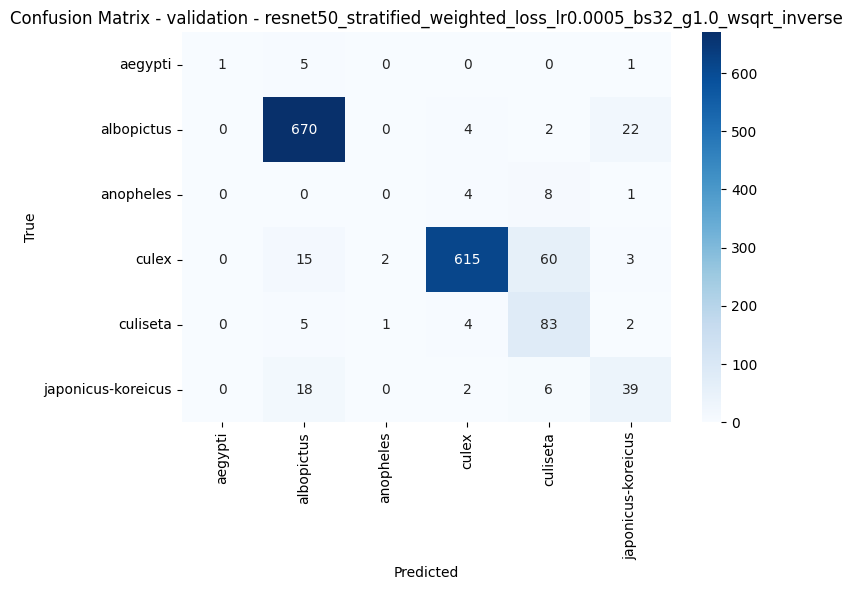


TEST Evaluation: resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse
Accuracy:           0.9065
Balanced Accuracy:  0.6844
Macro Precision:    0.7258
Macro Recall:       0.6844
Macro F1:           0.6574
Weighted F1:        0.9115
ROC-AUC:            0.9456

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,1.000000,0.285714,0.444444,7
1,albopictus,0.964549,0.934192,0.949128,699
2,anopheles,0.214286,0.500000,0.300000,12
3,culex,0.965465,0.923851,0.944200,696
4,culiseta,0.617021,0.915789,0.737288,95
5,japonicus-koreicus,0.593220,0.546875,0.569106,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.2857    0.4444         7
        albopictus     0.9645    0.9342    0.9491       699
         anopheles     0.2143    0.5000    0.3000        12
             culex     0.9655    0.9239    0.9442       696
          culiseta     0.6170    0.9158    0.7373        95
japonicus-koreicus     0.5932    0.5469    0.5691        64

          accuracy                         0.9065      1573
         macro avg     0.7258    0.6844    0.6574      1573
      weighted avg     0.9233    0.9065    0.9115      1573



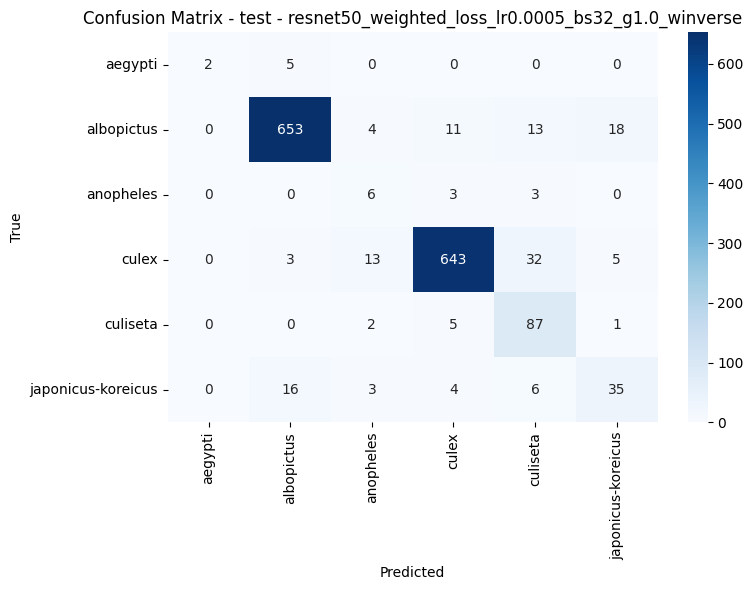


TEST Evaluation: resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse
Accuracy:           0.8474
Balanced Accuracy:  0.6344
Macro Precision:    0.5646
Macro Recall:       0.6344
Macro F1:           0.5731
Weighted F1:        0.8676
ROC-AUC:            0.9154

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.250000,0.142857,0.181818,7
1,albopictus,0.961872,0.793991,0.869906,699
2,anopheles,0.250000,0.416667,0.312500,12
3,culex,0.950292,0.933908,0.942029,696
4,culiseta,0.723810,0.800000,0.760000,95
5,japonicus-koreicus,0.251366,0.718750,0.372470,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9619    0.7940    0.8699       699
         anopheles     0.2500    0.4167    0.3125        12
             culex     0.9503    0.9339    0.9420       696
          culiseta     0.7238    0.8000    0.7600        95
japonicus-koreicus     0.2514    0.7188    0.3725        64

          accuracy                         0.8474      1573
         macro avg     0.5646    0.6344    0.5731      1573
      weighted avg     0.9049    0.8474    0.8676      1573



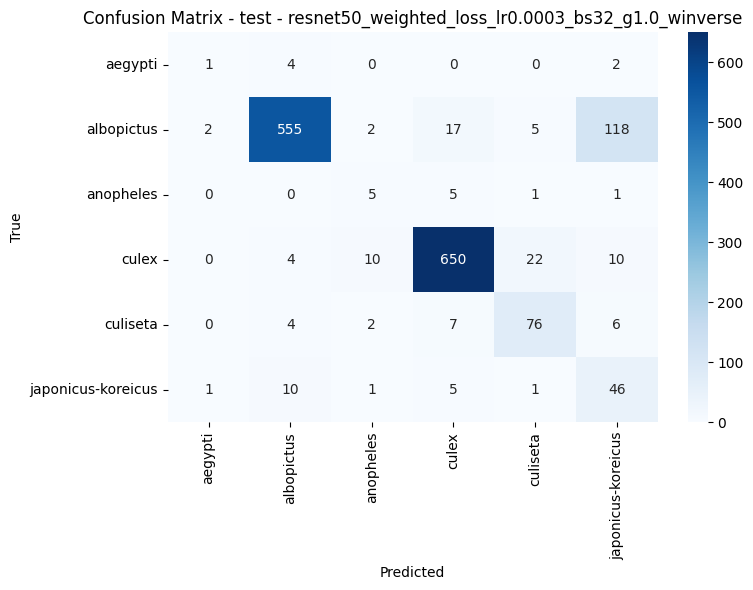


TEST Evaluation: resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse
Accuracy:           0.8843
Balanced Accuracy:  0.6139
Macro Precision:    0.5407
Macro Recall:       0.6139
Macro F1:           0.5696
Weighted F1:        0.8890
ROC-AUC:            0.9295

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.000000,0.000000,0.000000,7
1,albopictus,0.944200,0.919886,0.931884,699
2,anopheles,0.300000,0.500000,0.375000,12
3,culex,0.951735,0.906609,0.928624,696
4,culiseta,0.573643,0.778947,0.660714,95
5,japonicus-koreicus,0.474359,0.578125,0.521127,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.0000    0.0000    0.0000         7
        albopictus     0.9442    0.9199    0.9319       699
         anopheles     0.3000    0.5000    0.3750        12
             culex     0.9517    0.9066    0.9286       696
          culiseta     0.5736    0.7789    0.6607        95
japonicus-koreicus     0.4744    0.5781    0.5211        64

          accuracy                         0.8843      1573
         macro avg     0.5407    0.6139    0.5696      1573
      weighted avg     0.8969    0.8843    0.8890      1573



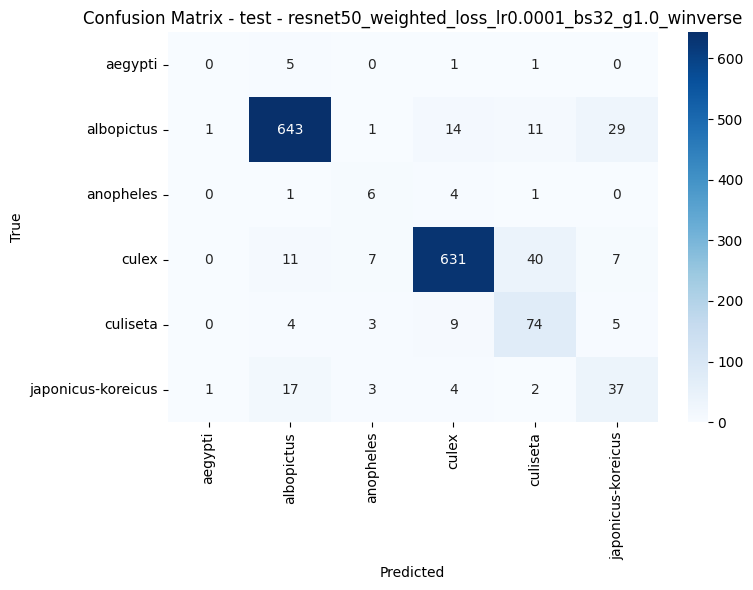


TEST Evaluation: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse
Accuracy:           0.9186
Balanced Accuracy:  0.6340
Macro Precision:    0.6115
Macro Recall:       0.6340
Macro F1:           0.6220
Weighted F1:        0.9205
ROC-AUC:            0.9523

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.285714,0.285714,0.285714,7
1,albopictus,0.952857,0.954220,0.953538,699
2,anopheles,0.153846,0.166667,0.160000,12
3,culex,0.968935,0.941092,0.954810,696
4,culiseta,0.766990,0.831579,0.797980,95
5,japonicus-koreicus,0.540541,0.625000,0.579710,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2857    0.2857    0.2857         7
        albopictus     0.9529    0.9542    0.9535       699
         anopheles     0.1538    0.1667    0.1600        12
             culex     0.9689    0.9411    0.9548       696
          culiseta     0.7670    0.8316    0.7980        95
japonicus-koreicus     0.5405    0.6250    0.5797        64

          accuracy                         0.9186      1573
         macro avg     0.6115    0.6340    0.6220      1573
      weighted avg     0.9229    0.9186    0.9205      1573



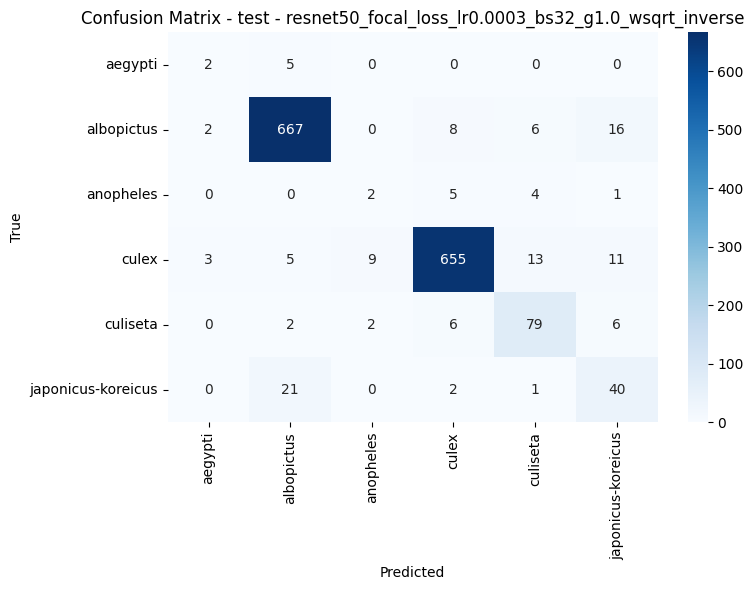


TEST Evaluation: resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.7521
Balanced Accuracy:  0.6080
Macro Precision:    0.5304
Macro Recall:       0.6080
Macro F1:           0.5027
Weighted F1:        0.8032
ROC-AUC:            0.9211

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,0.250000,0.142857,0.181818,7
1,albopictus,0.952577,0.660944,0.780405,699
2,anopheles,0.065934,0.500000,0.116505,12
3,culex,0.944620,0.857759,0.899096,696
4,culiseta,0.788235,0.705263,0.744444,95
5,japonicus-koreicus,0.181159,0.781250,0.294118,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     0.2500    0.1429    0.1818         7
        albopictus     0.9526    0.6609    0.7804       699
         anopheles     0.0659    0.5000    0.1165        12
             culex     0.9446    0.8578    0.8991       696
          culiseta     0.7882    0.7053    0.7444        95
japonicus-koreicus     0.1812    0.7812    0.2941        64

          accuracy                         0.7521      1573
         macro avg     0.5304    0.6080    0.5027      1573
      weighted avg     0.8979    0.7521    0.8032      1573



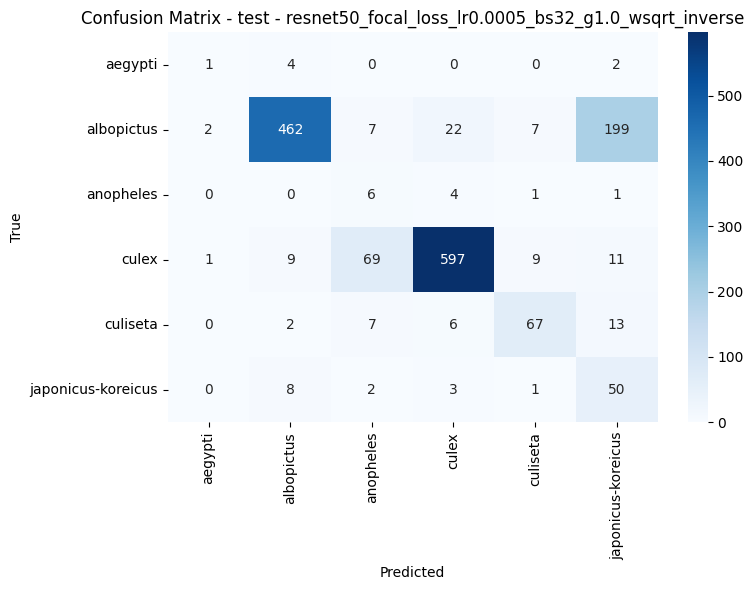


TEST Evaluation: resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse
Accuracy:           0.8881
Balanced Accuracy:  0.5927
Macro Precision:    0.7466
Macro Recall:       0.5927
Macro F1:           0.5815
Weighted F1:        0.8906
ROC-AUC:            0.9293

Per-class metrics:


,class_name,precision,recall,f1,support
0,aegypti,1.000000,0.142857,0.250000,7
1,albopictus,0.928969,0.954220,0.941426,699
2,anopheles,0.500000,0.083333,0.142857,12
3,culex,0.978896,0.866379,0.919207,696
4,culiseta,0.520958,0.915789,0.664122,95
5,japonicus-koreicus,0.550725,0.593750,0.571429,64



Classification report:
                    precision    recall  f1-score   support

           aegypti     1.0000    0.1429    0.2500         7
        albopictus     0.9290    0.9542    0.9414       699
         anopheles     0.5000    0.0833    0.1429        12
             culex     0.9789    0.8664    0.9192       696
          culiseta     0.5210    0.9158    0.6641        95
japonicus-koreicus     0.5507    0.5938    0.5714        64

          accuracy                         0.8881      1573
         macro avg     0.7466    0.5927    0.5815      1573
      weighted avg     0.9081    0.8881    0.8906      1573



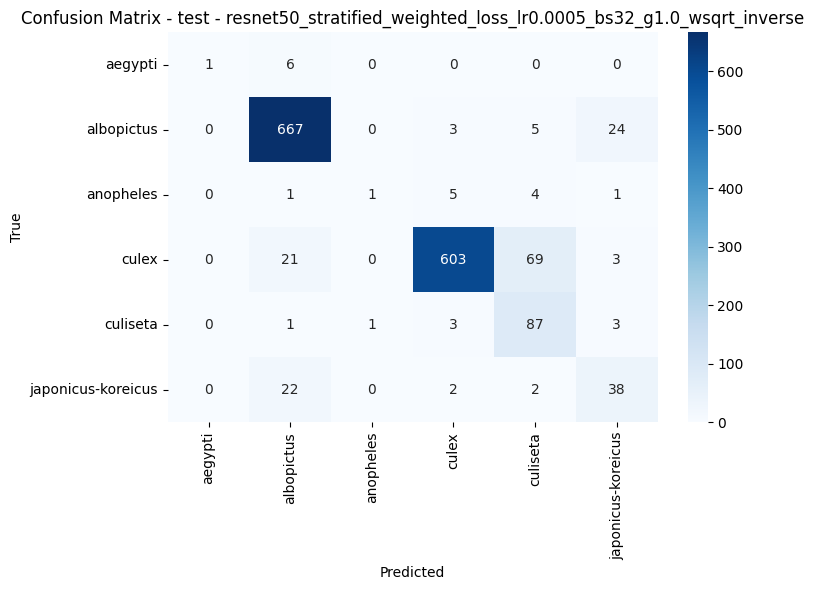


===== Detailed Evaluation Summary =====


,split,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_ovr
15,test,resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_i...,0.918627,0.634045,0.611481,0.634045,0.621959,0.922906,0.918627,0.920471,0.952323
3,train,resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_i...,0.967298,0.975035,0.957683,0.975035,0.966125,0.967713,0.967298,0.967364,0.999039
9,validation,resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_i...,0.912270,0.612416,0.627632,0.612416,0.615040,0.914386,0.912270,0.912794,0.922736
16,test,resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_i...,0.752066,0.608012,0.530421,0.608012,0.502731,0.897854,0.752066,0.803236,0.921072
4,train,resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_i...,0.874506,0.922889,0.835697,0.922889,0.862486,0.912489,0.874506,0.880487,0.994807
10,validation,resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_i...,0.748252,0.639025,0.527017,0.639025,0.524904,0.880205,0.748252,0.796863,0.928660
17,test,resnet50_stratified_weighted_loss_lr0.0005_bs3...,0.888112,0.592722,0.746591,0.592722,0.581507,0.908073,0.888112,0.890624,0.929278
5,train,resnet50_stratified_weighted_loss_lr0.0005_bs3...,0.956942,0.978595,0.948963,0.978595,0.962046,0.961120,0.956942,0.957369,0.999096
11,validation,resnet50_stratified_weighted_loss_lr0.0005_bs3...,0.895105,0.576886,0.668829,0.576886,0.561449,0.908650,0.895105,0.896689,0.935996
14,test,resnet50_weighted_loss_lr0.0001_bs32_g1.0_winv...,0.884298,0.613928,0.540656,0.613928,0.569558,0.896922,0.884298,0.888957,0.929546


In [21]:
# detailed evaluation for train / validation / test

detailed_eval_list = []

all_split_results = {
    "train": all_train_results,
    "validation": all_val_results,
    "test": all_test_results
}

for split_name, split_results in all_split_results.items():
    for model_name, data in split_results.items():

        print(f"\n==============================")
        print(f"{split_name.upper()} Evaluation: {model_name}")
        print(f"==============================")

        all_preds = data["preds"]
        all_labels = data["labels"]
        all_probs = data["probs"]

        acc = accuracy_score(all_labels, all_preds)
        bal_acc = balanced_accuracy_score(all_labels, all_preds)

        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average=None,
            zero_division=0
        )

        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0
        )

        precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="weighted",
            zero_division=0
        )

        try:
            roc_auc = roc_auc_score(
                all_labels,
                all_probs,
                multi_class="ovr",
                average="macro"
            )
        except:
            roc_auc = np.nan

        cm = confusion_matrix(all_labels, all_preds)

        print(f"Accuracy:           {acc:.4f}")
        print(f"Balanced Accuracy:  {bal_acc:.4f}")
        print(f"Macro Precision:    {precision_macro:.4f}")
        print(f"Macro Recall:       {recall_macro:.4f}")
        print(f"Macro F1:           {f1_macro:.4f}")
        print(f"Weighted F1:        {f1_weighted:.4f}")
        print(f"ROC-AUC:            {roc_auc:.4f}")

        per_class_df = pd.DataFrame({
            "class_name": class_names,
            "precision": precision_per_class,
            "recall": recall_per_class,
            "f1": f1_per_class,
            "support": support
        })

        print("\nPer-class metrics:")
        display(per_class_df)

        print("\nClassification report:")
        print(classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4,
            zero_division=0
        ))

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix - {split_name} - {model_name}")
        plt.tight_layout()
        plt.show()

        detailed_eval_list.append({
            "split": split_name,
            "model": model_name,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "macro_precision": precision_macro,
            "macro_recall": recall_macro,
            "macro_f1": f1_macro,
            "weighted_precision": precision_weighted,
            "weighted_recall": recall_weighted,
            "weighted_f1": f1_weighted,
            "roc_auc_ovr": roc_auc
        })

detailed_eval_df = pd.DataFrame(detailed_eval_list)

print("\n===== Detailed Evaluation Summary =====")
display(detailed_eval_df.sort_values(by=["model", "split"]))

detailed_eval_df.to_csv("/kaggle/working/detailed_eval_results.csv", index=False)

Best method by macro F1: resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse


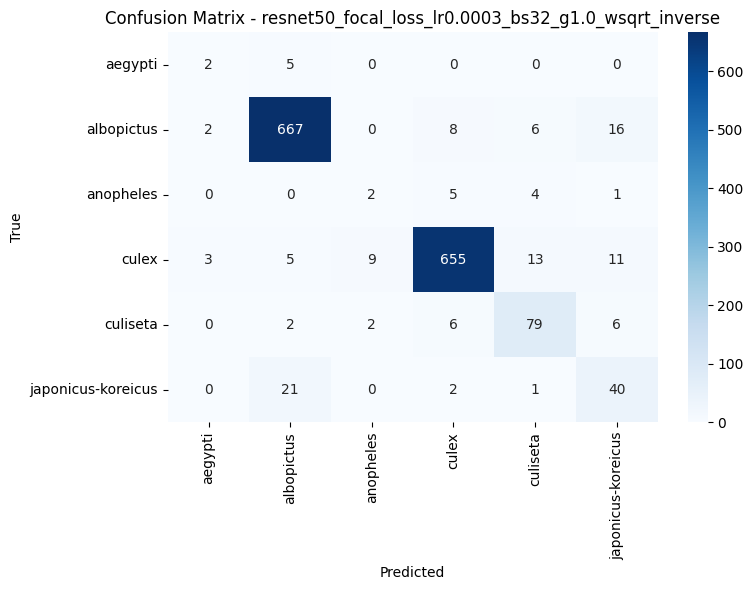

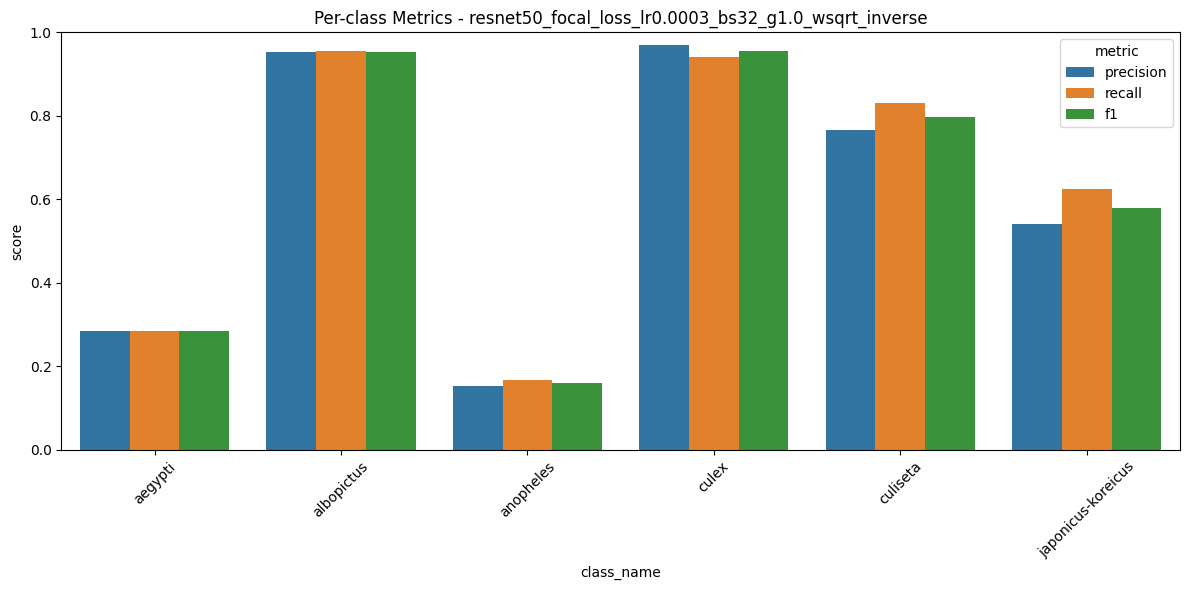

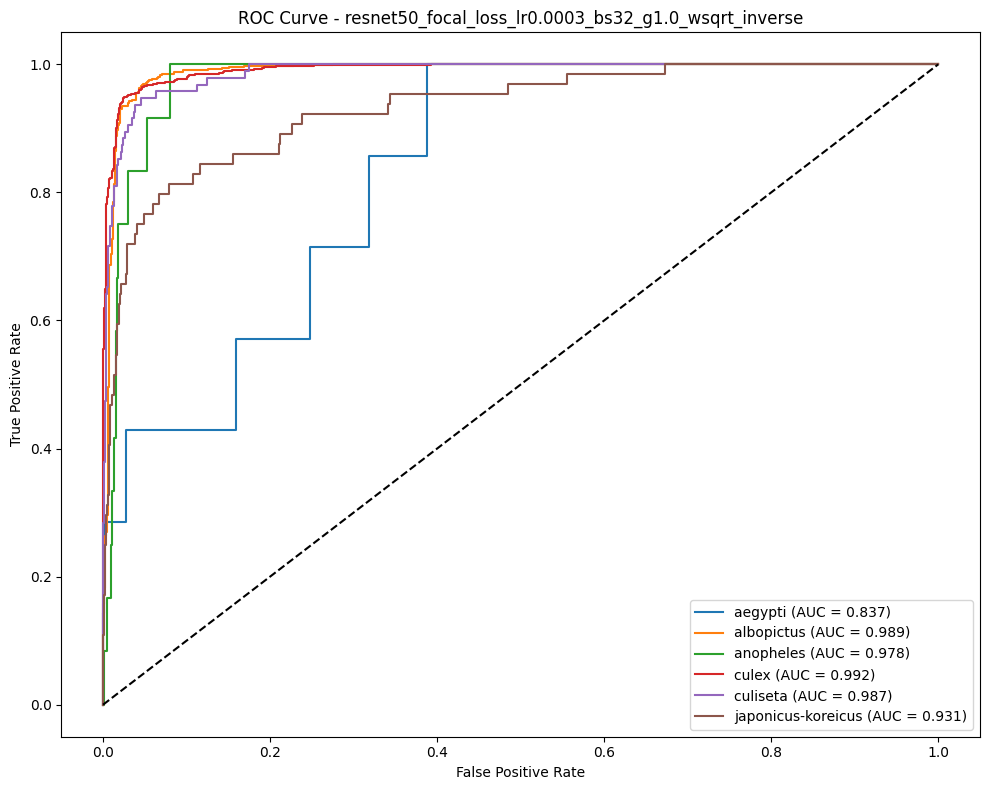

Saved best method plots to: /kaggle/working/best_method_plots


In [22]:
detailed_eval_df = pd.DataFrame(detailed_eval_list)

# =========================
# SAVE BEST METHOD PLOTS
# =========================

plot_dir = Path("/kaggle/working/best_method_plots")
plot_dir.mkdir(parents=True, exist_ok=True)

# best method by macro F1 = best for imbalance/fairness
best_row = detailed_eval_df.sort_values(by="macro_f1", ascending=False).iloc[0]
best_name = best_row["model"]

print("Best method by macro F1:", best_name)

data = all_test_results[best_name]
all_preds = data["preds"]
all_labels = data["labels"]
all_probs = data["probs"]

# 1. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
#plt.savefig(plot_dir / f"{best_name}_confusion_matrix.png", dpi=300)
plt.show()

# 2. Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None,
    zero_division=0
)

per_class_df = pd.DataFrame({
    "class_name": class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

plot_df = per_class_df.melt(
    id_vars=["class_name", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title(f"Per-class Metrics - {best_name}")
plt.tight_layout()
#plt.savefig(plot_dir / f"{best_name}_per_class_metrics.png", dpi=300)
plt.show()

# 3. ROC curve
n_classes = len(class_names)
all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_name}")
plt.legend()
plt.tight_layout()
#plt.savefig(plot_dir / f"{best_name}_roc_curve.png", dpi=300)
plt.show()

print("Saved best method plots to:", plot_dir)

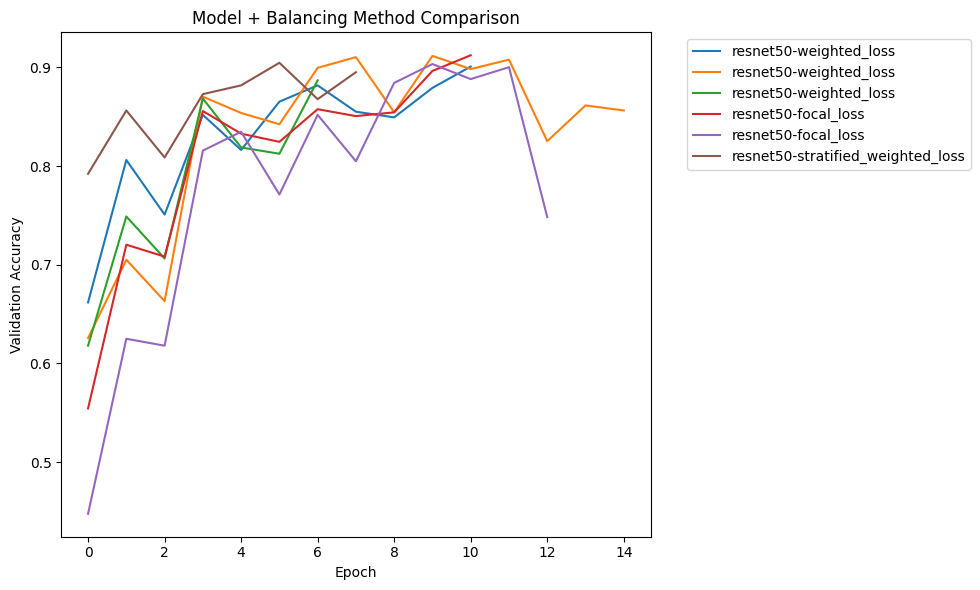

resnet50 + weighted_loss → Best: 0.9008
resnet50 + weighted_loss → Best: 0.9116
resnet50 + weighted_loss → Best: 0.8868
resnet50 + focal_loss → Best: 0.9123
resnet50 + focal_loss → Best: 0.9034
resnet50 + stratified_weighted_loss → Best: 0.9046


In [23]:
# validation accuracy plot
plt.figure(figsize=(10,6))

for r in all_results:
    label = f"{r['model']}-{r['method']}"
    plt.plot(r["val_acc_history"], label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Model + Balancing Method Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

for r in all_results:
    print(f"{r['model']} + {r['method']} → Best: {r['best_val_acc']:.4f}")


===== Results for resnet50_weighted_loss_lr0.0005_bs32_g1.0_winverse =====
Test Accuracy: 0.9065
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.285714  0.444444        7
1          albopictus   0.964549  0.934192  0.949128      699
2           anopheles   0.214286  0.500000  0.300000       12
3               culex   0.965465  0.923851  0.944200      696
4            culiseta   0.617021  0.915789  0.737288       95
5  japonicus-koreicus   0.593220  0.546875  0.569106       64


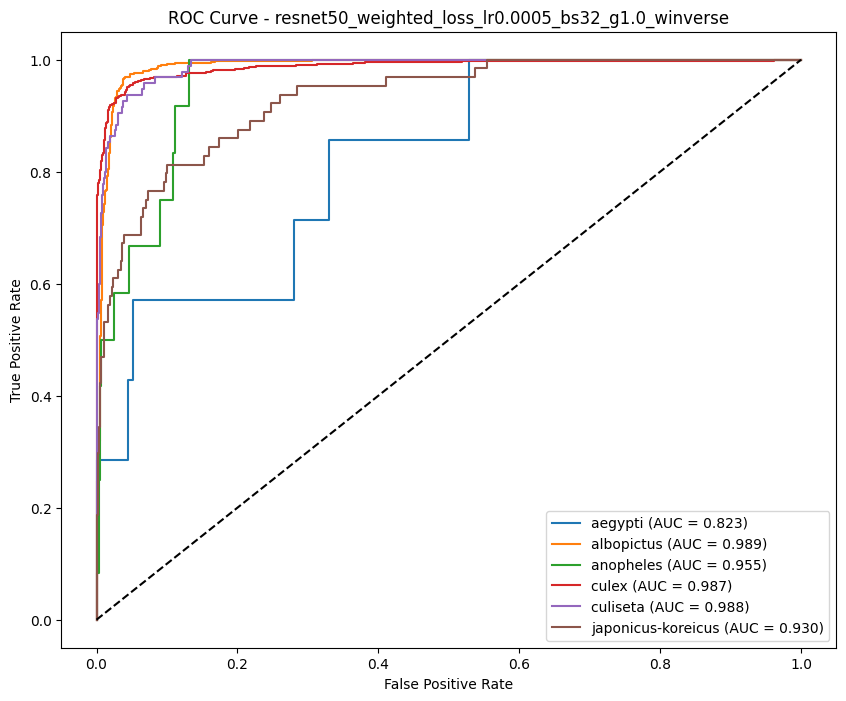

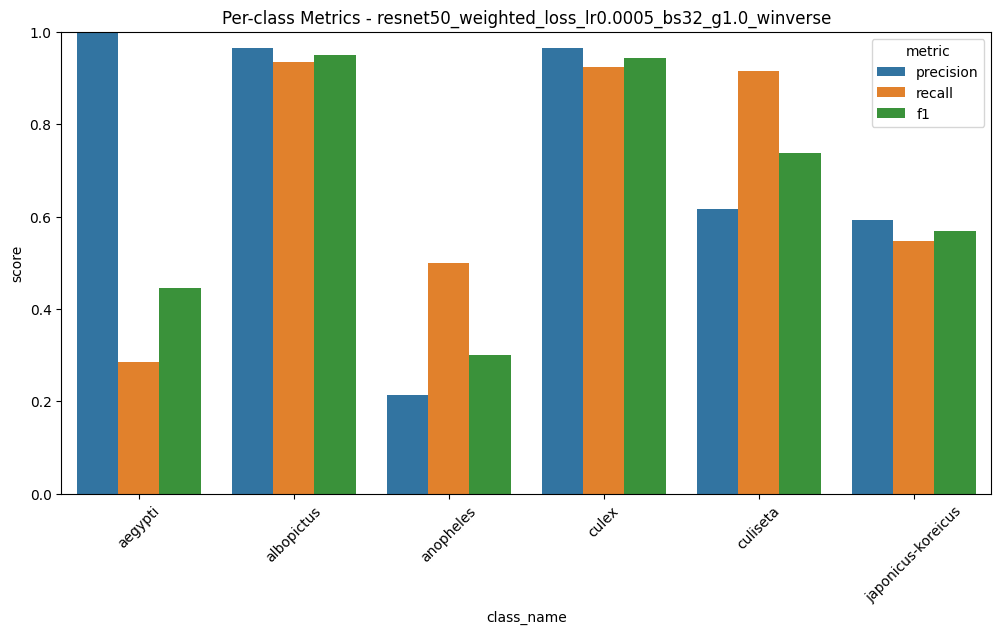


===== Results for resnet50_weighted_loss_lr0.0003_bs32_g1.0_winverse =====
Test Accuracy: 0.8474
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.961872  0.793991  0.869906      699
2           anopheles   0.250000  0.416667  0.312500       12
3               culex   0.950292  0.933908  0.942029      696
4            culiseta   0.723810  0.800000  0.760000       95
5  japonicus-koreicus   0.251366  0.718750  0.372470       64


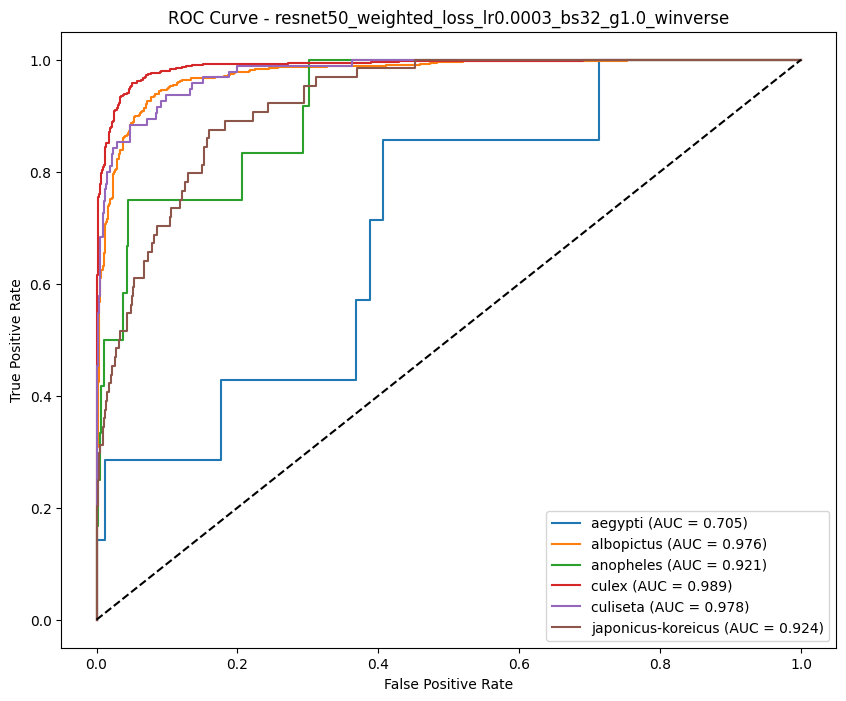

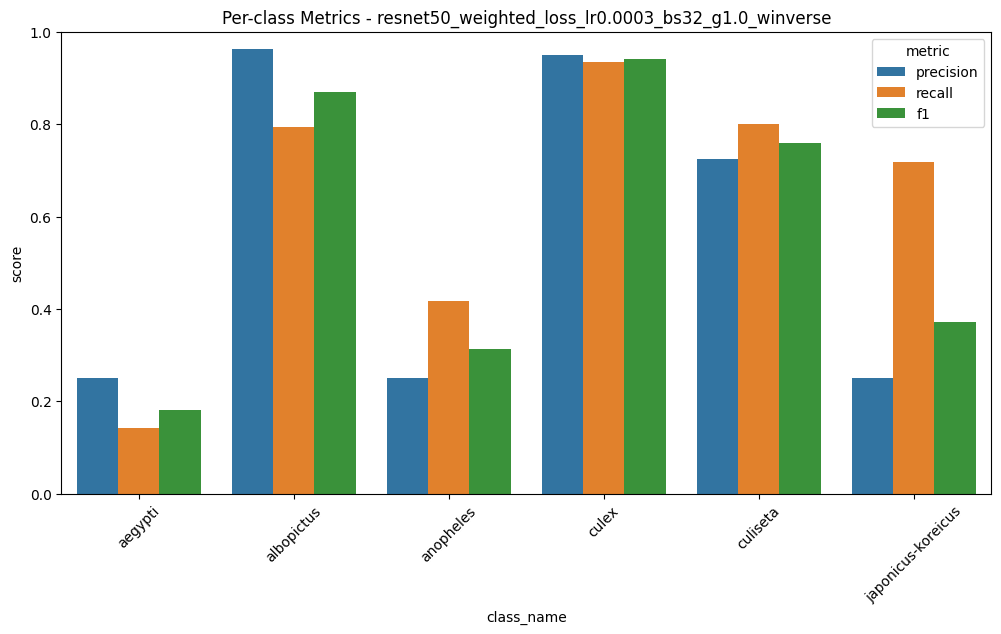


===== Results for resnet50_weighted_loss_lr0.0001_bs32_g1.0_winverse =====
Test Accuracy: 0.8843
           class_name  precision    recall        f1  support
0             aegypti   0.000000  0.000000  0.000000        7
1          albopictus   0.944200  0.919886  0.931884      699
2           anopheles   0.300000  0.500000  0.375000       12
3               culex   0.951735  0.906609  0.928624      696
4            culiseta   0.573643  0.778947  0.660714       95
5  japonicus-koreicus   0.474359  0.578125  0.521127       64


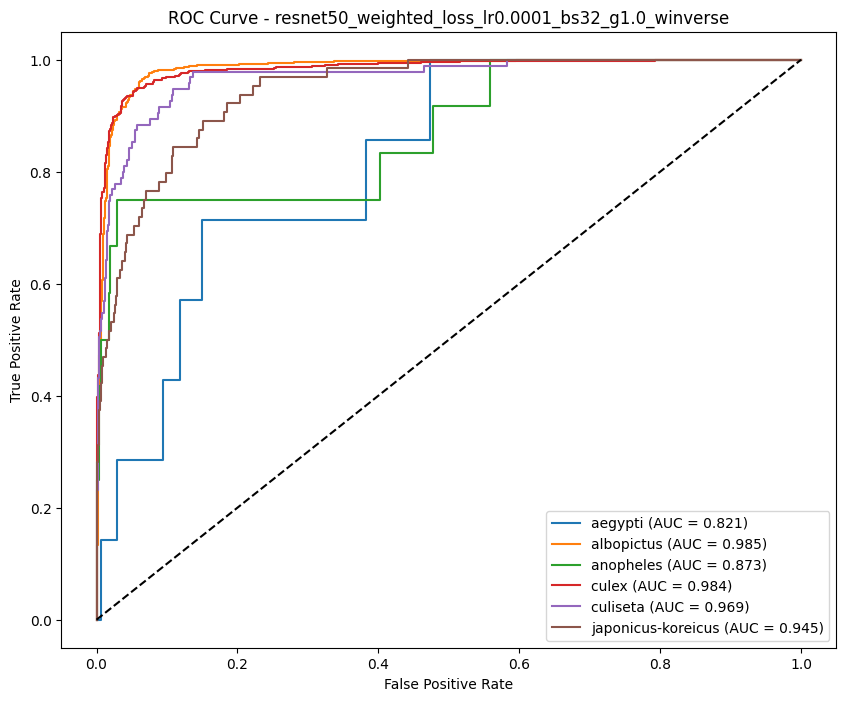

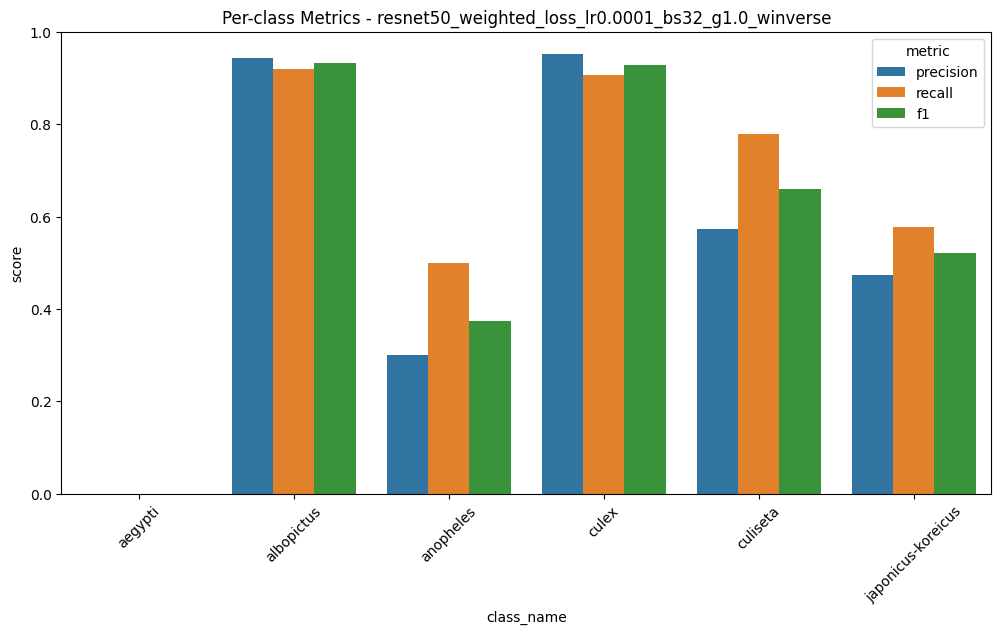


===== Results for resnet50_focal_loss_lr0.0003_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.9186
           class_name  precision    recall        f1  support
0             aegypti   0.285714  0.285714  0.285714        7
1          albopictus   0.952857  0.954220  0.953538      699
2           anopheles   0.153846  0.166667  0.160000       12
3               culex   0.968935  0.941092  0.954810      696
4            culiseta   0.766990  0.831579  0.797980       95
5  japonicus-koreicus   0.540541  0.625000  0.579710       64


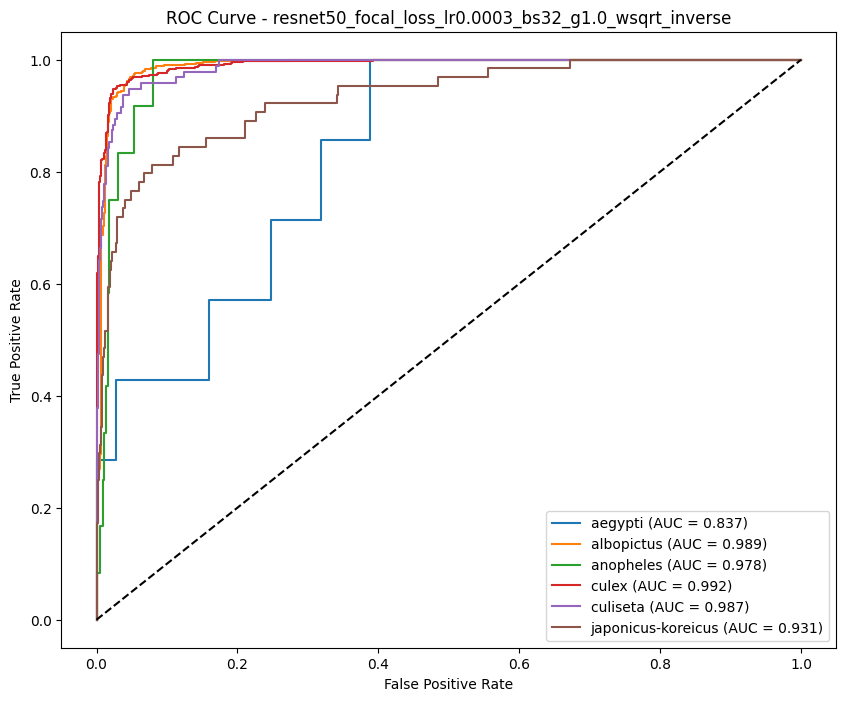

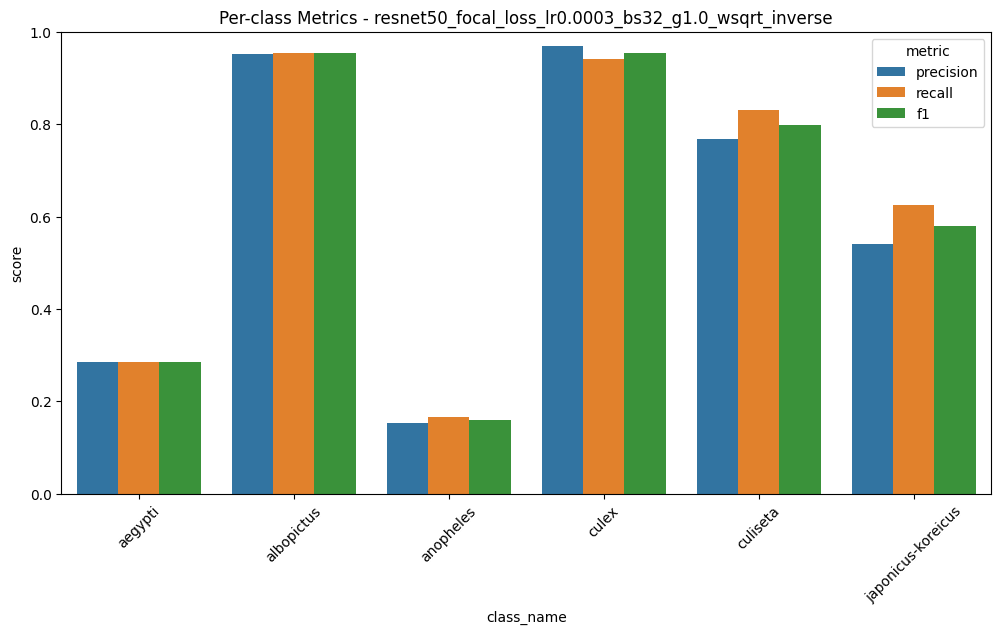


===== Results for resnet50_focal_loss_lr0.0005_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.7521
           class_name  precision    recall        f1  support
0             aegypti   0.250000  0.142857  0.181818        7
1          albopictus   0.952577  0.660944  0.780405      699
2           anopheles   0.065934  0.500000  0.116505       12
3               culex   0.944620  0.857759  0.899096      696
4            culiseta   0.788235  0.705263  0.744444       95
5  japonicus-koreicus   0.181159  0.781250  0.294118       64


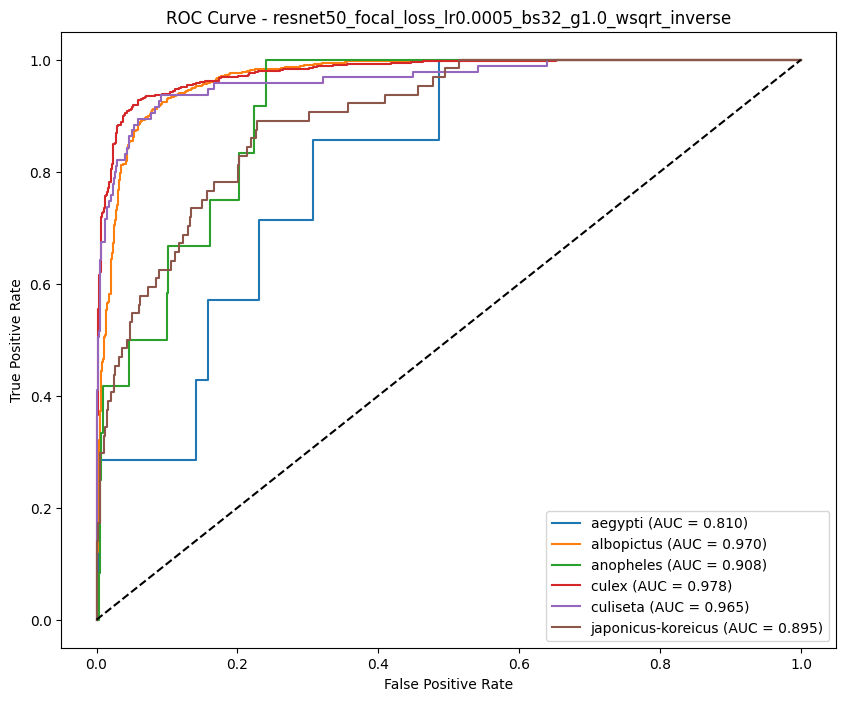

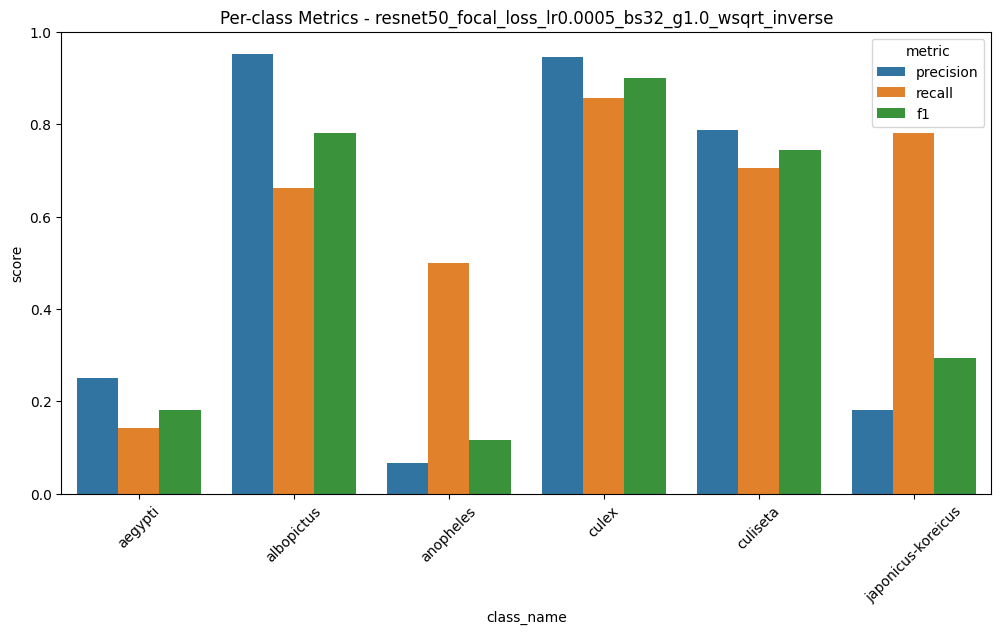


===== Results for resnet50_stratified_weighted_loss_lr0.0005_bs32_g1.0_wsqrt_inverse =====
Test Accuracy: 0.8881
           class_name  precision    recall        f1  support
0             aegypti   1.000000  0.142857  0.250000        7
1          albopictus   0.928969  0.954220  0.941426      699
2           anopheles   0.500000  0.083333  0.142857       12
3               culex   0.978896  0.866379  0.919207      696
4            culiseta   0.520958  0.915789  0.664122       95
5  japonicus-koreicus   0.550725  0.593750  0.571429       64


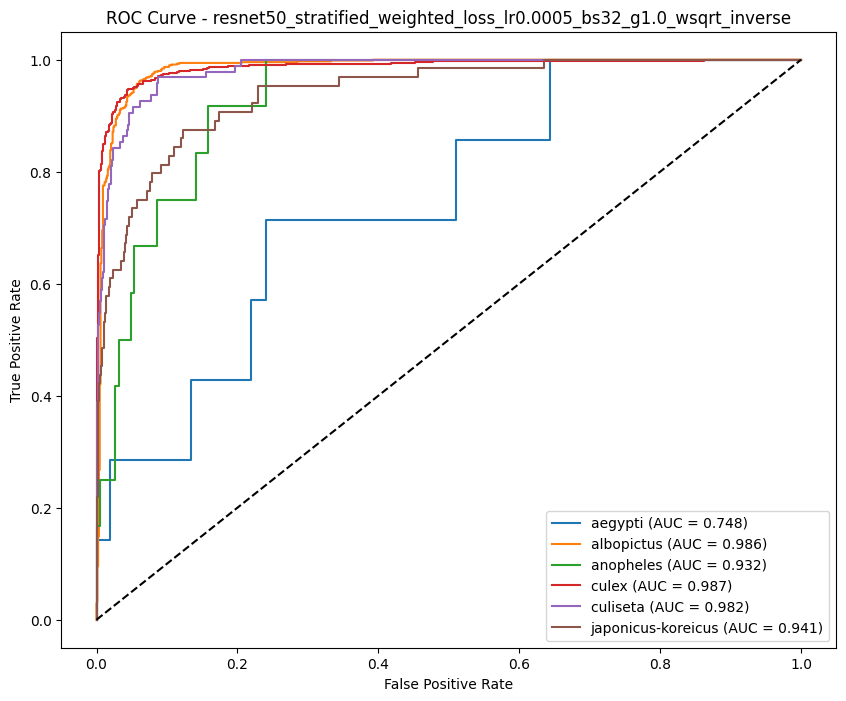

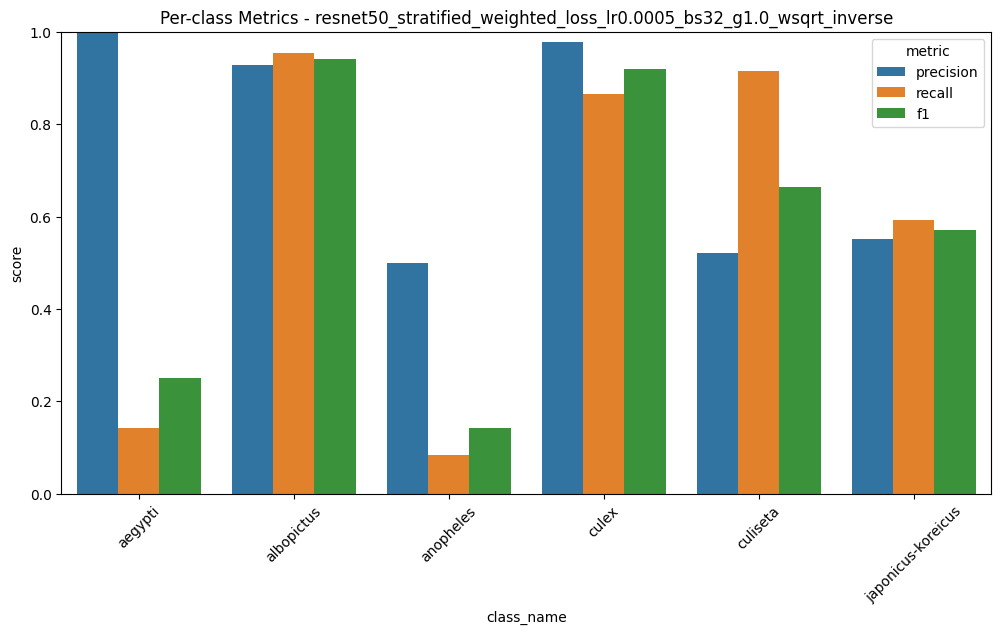

      model                    method  \
3  resnet50                focal_loss   
1  resnet50             weighted_loss   
5  resnet50  stratified_weighted_loss   
4  resnet50                focal_loss   
0  resnet50             weighted_loss   
2  resnet50             weighted_loss   

                                     val_acc_history  best_val_acc  \
3  [0.554354736172918, 0.7202797202797203, 0.7082...      0.912270   
1  [0.6255562619198983, 0.7050222504767959, 0.663...      0.911634   
5  [0.7921169739351558, 0.856325492689129, 0.8086...      0.904641   
4  [0.44755244755244755, 0.6249205340114431, 0.61...      0.903369   
0  [0.6617927527018436, 0.8061029879211697, 0.750...      0.900826   
2  [0.6179275270184361, 0.7488874761602035, 0.706...      0.886840   

   best_val_balanced_acc                           val_balanced_acc_history  \
3               0.637290  [0.4990245347990037, 0.6308292735174214, 0.603...   
1               0.651849  [0.48379717348356044, 0.6061965367192

In [24]:
#only for test set plots

summary_list = []

for model_name, data in all_test_results.items():
    print(f"\n===== Results for {model_name} =====")

    all_preds = data["preds"]
    all_labels = data["labels"]
    all_probs = data["probs"]
    
    # ===== Accuracy =====
    acc = accuracy_score(all_labels, all_preds)
    print("Test Accuracy:", round(acc, 4))
    
    # ===== Precision / Recall / F1 per class =====
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    per_class_df = pd.DataFrame({
        "class_name": class_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    })
    print(per_class_df)

    # ===== ROC Curve =====
    n_classes = len(class_names)
    all_labels_bin = label_binarize(all_labels, classes=range(n_classes))

    plt.figure(figsize=(10, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_i:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

    # ===== Bar chart =====
    plot_df = per_class_df.melt(
        id_vars=["class_name", "support"],
        value_vars=["precision", "recall", "f1"],
        var_name="metric",
        value_name="score"
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x="class_name", y="score", hue="metric")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.title(f"Per-class Metrics - {model_name}")
    plt.show()

    
    # ===== Macro metrics =====
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    # ===== Store summary =====
    summary_list.append({
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_ovr": roc_auc
    })

df = pd.DataFrame(all_results)
print(df.sort_values(by="best_val_acc", ascending=False))

df = pd.DataFrame(summary_list)
print(df.sort_values(by="f1_macro", ascending=False))

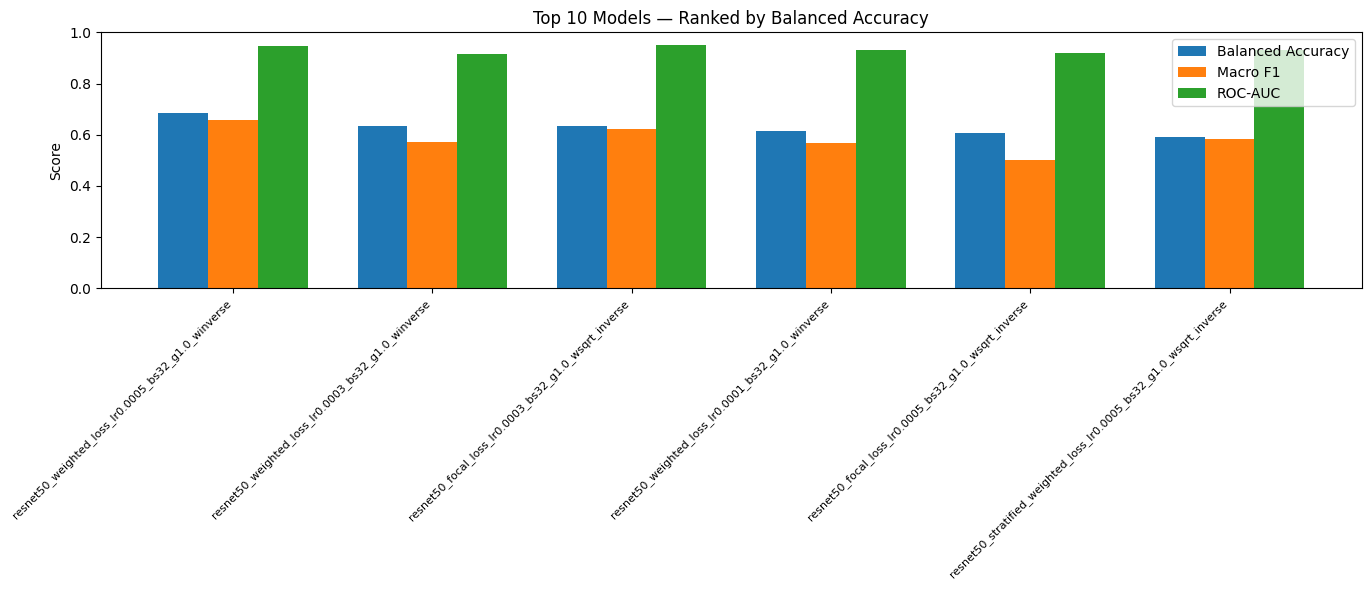

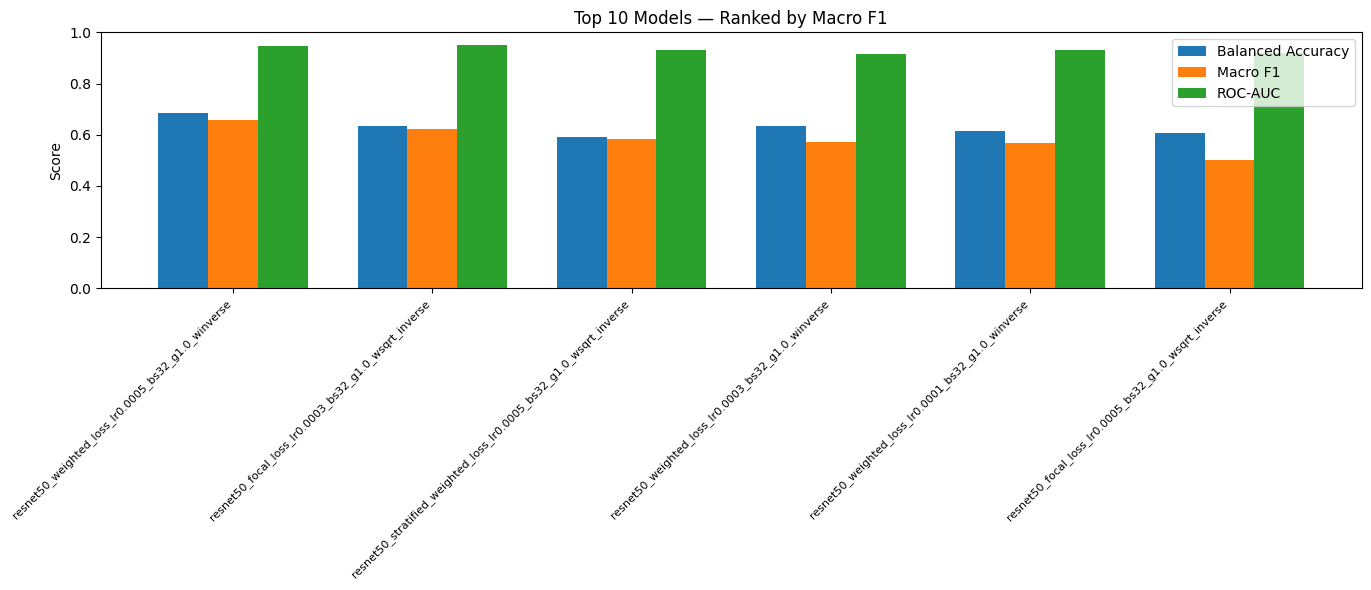

In [25]:
# Pull test-split rows from detailed_eval_df which has balanced_accuracy
test_eval_df = detailed_eval_df[detailed_eval_df["split"] == "test"].copy()

metrics = ["balanced_accuracy", "macro_f1", "roc_auc_ovr"]

def plot_top10(df, rank_by, title):
    top10 = df.sort_values(by=rank_by, ascending=False).head(10)
    x = range(len(top10))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar([i - width for i in x], top10["balanced_accuracy"], width, label="Balanced Accuracy")
    ax.bar([i         for i in x], top10["macro_f1"],          width, label="Macro F1")
    ax.bar([i + width for i in x], top10["roc_auc_ovr"],       width, label="ROC-AUC")

    ax.set_xticks(list(x))
    ax.set_xticklabels(top10["model"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_top10(test_eval_df, rank_by="balanced_accuracy", title="Top 10 Models — Ranked by Balanced Accuracy")
plot_top10(test_eval_df, rank_by="macro_f1",          title="Top 10 Models — Ranked by Macro F1")

In [26]:
#best = max(all_results, key=lambda x: x["best_val_acc"])
best = max(all_results, key=lambda x: x["best_val_balanced_acc"])

print("Best Model:", best["model"])
print("Best Method:", best["method"])
print("Best Accuracy:", best["best_val_acc"])
print("Best Balanced Acc:", best["best_val_balanced_acc"])

Best Model: resnet50
Best Method: focal_loss
Best Accuracy: 0.9033693579148124
Best Balanced Acc: 0.6605917999346945


# Save Outputs

In [27]:
torch.save(
    best_model_state,
    output_dir / f"BEST_MODEL_{best_run_name}.pth"
)

print("Saved best model:", best_run_name)
print("Best val acc:", best_overall_acc)


torch.save({
    "model_state_dict": best_model_state,
    "run_name": best_run_name,
    "best_val_acc": best_overall_acc,
    "best_val_balanced_acc": best_overall_balanced_acc
}, output_dir / "BEST_MODEL_FULL.pth")



with open(output_dir / "BEST_MODEL_NAME.txt", "w") as f:
    f.write(best_run_name)

results_df.to_csv(output_dir / "training_results.csv", index=False)
detailed_eval_df.to_csv(output_dir / "detailed_eval_results.csv", index=False)
summary_df = pd.DataFrame(summary_list)
summary_df.to_csv(output_dir / "test_summary.csv", index=False)

Saved best model: resnet50_focal_loss_lr0.0005_bs32_ep30_g1.0_wsqrt_inverse
Best val acc: 0.9033693579148124
